In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


from bias_scores import ScoreSum
from utils import clean_unnamed
import os
import time
import random
random.seed(42)


In [ ]:
dict_model_ft_non = {"bert-base-cased":"ft-models",
                       "distilbert-distilbert-base-cased":"ft-models",
                       "cardiffnlp-twitter-xlm-roberta-base":"ft-models",
                       "cardiffnlp-twitter-roberta-base":"ft-models",
                       "google-bert-bert-base-multilingual-cased":"ft-models",
                       "cardiffnlp-sentiment":"off-the-shelf",
                       "cardiffnlp-hate":"off-the-shelf",
                       "cardiffnlp-offensive":"off-the-shelf",
                       "llama38B":"ft-models",
                       "llama38B_128":"ft-models",
                       "qwen":"ft-models",
                       "mistral":"ft-models"}

dict_model_meta_template = {
                 "EEC":{"ft-models":{
                    #"google-bert-bert-base-multilingual-cased":"multi-BERT",
                    #"FacebookAI-xlm-roberta-base":"roberta-xlm",
                    #"vinai-bertweet-base":"BERT-tweet",
                    "bert-base-cased": "BERT",
                    "distilbert-distilbert-base-cased": "distil-BERT",
                    "cardiffnlp-twitter-xlm-roberta-base":"cardiffnlp-roberta-xlm",
                    "cardiffnlp-twitter-roberta-base":"cardiffnlp-roberta",
                    "llama38B":"llama38B",
                    "llama38B_128":"llama38B_128",
                    "qwen":"Qwen",
                    "mistral":"Mistral",

                    },
                 "off-the-shelf":{
                      "cardiffnlp-sentiment":"cardiffnlp-sentiment",
                     # "cardiffnlp-emotion":"cardiffnlp-emotion"
                      }},
                       "IPTTS": {"ft-models":{
                    "bert-base-cased": "BERT",
                    "distilbert-distilbert-base-cased": "distil-BERT",
                    "google-bert-bert-base-multilingual-cased":"multi-BERT",
                    "llama38B":"llama38B",
                     "llama38B_128":"llama38B_128",
                     "qwen":"Qwen"},
                 "off-the-shelf":{
                      "cardiffnlp-hate":"cardiffnlp-hate",
                      "cardiffnlp-offensive":"cardiffnlp-offensive",
}}}



In [ ]:
class BiasScores:
    def __init__(self,dict_test_model,l_domains,l_models_llm,prompt,template,name_experiment,bias_type):
        self.dict_models = dict_test_model
        self.l_domains = l_domains
        self.l_models_llm = l_models_llm
        self.prompt = prompt
        self.template = template
        self.name_experiment = name_experiment
        self.bias_type = bias_type

    def wikipedia_talks_NOE_balance(self,model_downstream):
        df_nontoxic =pd.read_csv(f"Scores/NOEs/wikipedia_talks/IPTTS/{model_downstream}/scores_wikipedia_talks_nontoxic_toxic.csv")
        df_toxic =pd.read_csv(f"Scores/NOEs/wikipedia_talks/IPTTS/{model_downstream}/scores_wikipedia_talks_toxic_toxic.csv")
        n_min = min(int(max(df_toxic["template_index"].unique())),int(max(df_nontoxic["template_index"].unique())))
        df_nontoxic = df_nontoxic[df_nontoxic["template_index"].isin(list(range(n_min)))]
        df_toxic = df_toxic[df_toxic["template_index"].isin(list(range(n_min)))]
        df_toxic["template_index"] = df_toxic["template_index"].apply(lambda x: x+1+n_min)
        df = pd.concat([df_nontoxic, df_toxic])
        df = df.reset_index(drop=True)
        df.to_csv(f"Scores/NOEs/wikipedia_talks/IPTTS/{model_downstream}/scores_wikipedia_talks.csv", index=False)

    def get_domain(self,path):
        for domain in ["tweets","wikipedia_talks","IMDB"]:
            if domain in path:
                return domain
        if "IMBD" in path:
            return "IMDB"
        return ""

    def get_llm(self,path):
        for llm in ["llama3_8","llama3_70","mixtral"]:
            if llm in path:
                return llm
        return self.get_domain(path)
    

    def sum_score_by_model(self, model_downstream):
        name_abrev_model = dict_model_meta_template[self.template][dict_model_ft_non[model_downstream]][model_downstream]
        model_original_name = model_downstream.split("_")[0]
        # path_scores = f"adaptation_llm/Scores/{model_downstream}/{self.template}/LLMs/{self.bias_type}/{self.name_experiment}/scores_{self.template}_{self.prompt}_all.csv"
        # path_scores = f"adaptation_llm/Scores/{model_downstream}/{self.template}/LLMs/{self.bias_type}/scores_{self.template}_{self.prompt}_all.csv"
        path_scores = f"adaptation_llm/Scores/{model_downstream}/{self.template}/LLMs/{self.bias_type}/{self.name_experiment}/scores_{self.template}_{self.prompt}_all.csv"
        path = Path( f"adaptation_llm/Scores/{model_downstream}/{self.template}/LLMs/{self.bias_type}/{self.name_experiment}")
        path.mkdir(parents=True, exist_ok=True)
        paths_templates = [f"adaptation_llm/Scores/{model_downstream}/{self.template}/template/{self.bias_type}/scores_{self.template}.csv"]
        # if self.template == "IPTTS":
        #     self.wikipedia_talks_NOE_balance(model_downstream)

        # paths_noes = [f"adaptation_llm/Scores/{model_downstream}/{self.template}/NOEs/{self.bias_type}/scores_{domain_i}.csv" for domain_i in self.l_domains if domain_i != "IMDB" ]
        # paths_noes += [f"adaptation_llm/Scores/{model_downstream}/{self.template}/NOEs/{self.bias_type}/scores_IMDB_V1.csv"]
        # paths_noes = [f"adaptation_llm/Scores/{model_downstream}/{self.template}/NOEs/{self.bias_type}/scores_{domain_i}_V1.csv" for domain_i in self.l_domains if "tweets" in domain_i or "IMDB" in domain_i  ]
        # paths_noes += [f"adaptation_llm/Scores/{model_downstream}/{self.template}/NOEs/{self.bias_type}/scores_{domain_i}.csv" for domain_i in self.l_domains if "wiki" in domain_i  ]
        paths_noes = [f"adaptation_llm/Scores/{model_downstream}/{self.template}/NOEs/{self.bias_type}/scores_{domain_i}.csv" for domain_i in self.l_domains   ]

        # path_llm = [f"adaptation_llm/Scores/{model_downstream}/{self.template}/LLMs/{self.bias_type}/{self.name_experiment}/scores_{model_ft}_{domain_}.csv" for model_ft in self.l_models_llm for domain_ in self.l_domains]
        path_llm = [f"adaptation_llm/Scores/{model_downstream}/{self.template}/LLMs/{self.bias_type}/scores_{model_ft}_{domain_}.csv" for model_ft in self.l_models_llm for domain_ in self.l_domains]

        l_dfs = []

        for path in paths_templates:
            # print(path)
            print(path)
            df = pd.read_csv(path)
            df = clean_unnamed(df)
            df["model"] = name_abrev_model
            df["template_type"] = f"{self.template}"
            df.to_csv(path,index=False)
            for k, domain_i in enumerate(self.l_domains):
                df = pd.read_csv(path)
                df["domain"] = domain_i
                l_dfs.append(df)

        for path in path_llm+paths_noes:
            # print(path)
            print(path)

            df = pd.read_csv(path)
            df = clean_unnamed(df)
            df["model"] = name_abrev_model
            index_word = path.index("scores_")
            len_word = len("scores_")
            df["domain"] = self.get_domain(path)
            df["template_type"] = self.get_llm(path)
            if  "scores_IMDB.csv" in path:
                
                print("max_IMDB",df["template_index"].max())
                sample_1000 = pd.Series(df["template_index"].unique()).sample(n=1000, random_state=42).tolist()
                # df = df[df["template_index"].isin(sample_1000)].reset_index(drop=True)
                df = df[df["template_index"].isin(sample_1000)].reset_index(drop=True)
                print("IMDB n NOEs",df["template_index"].nunique())
                print("shape IMDB",df.shape)
            if "scores_tweets.csv" in path:
            #     path = path.replace("_tweets.csv","_tweets_V1.csv")
            #                 # print(path)
            #     df = pd.read_csv(path)
            #     df = clean_unnamed(df)
            #     df["model"] = name_abrev_model
            #     index_word = path.index("scores_")
            #     len_word = len("scores_")
            #     df["domain"] = self.get_domain(path)
            #     df["template_type"] = self.get_llm(path)
                # sample_700 = pd.Series(df["template_index"].unique()).sample(n=70, random_state=2).tolist()
                # df = df[df["template_index"].isin(list(range(515)))].reset_index(drop=True)
                # print("max_Tweets",df["template_index"].max())
                print("max_Tweets",df["template_index"].max())
                print("total_Tweets",df["template_index"].nunique())
                print("shape Tweets",df.shape)

            l_dfs.append(df)

        df_all_scores = pd.concat(l_dfs, axis = 0)
        df_all_scores = df_all_scores.drop(columns=["template"])
        df_all_scores.to_csv(path_scores,index=False)

    def VBCM_all_models(self, MCM = False):
        L_VBCM_NOEs = []
        L_VBCM_LLMS_Templates= []
        L_MCM = []
        for model_downstream in self.dict_models[self.template]:
            
            name_abrev_model = dict_model_meta_template[self.template][dict_model_ft_non[model_downstream]][model_downstream]
            model_original_name = model_downstream.split("_")[0]
            print(model_downstream)
            # path_scores = f"adaptation_llm/Scores/{model_downstream}/{self.template}/LLMs/{self.bias_type}/{self.name_experiment}/scores_{self.template}_{self.prompt}_all.csv"
            path_scores = f"adaptation_llm/Scores/{model_downstream}/{self.template}/LLMs/{self.bias_type}/{self.name_experiment}/scores_{self.template}_{self.prompt}_all.csv"

            if "llama" not in model_downstream: #not os.path.exists(path_scores):# or model_downstream in ["llama38B_128","LlaMA3-8B"]:
                self.sum_score_by_model(model_downstream)

            path = Path( f"adaptation_llm/Scores/sum/{self.name_experiment}")
            path.mkdir(parents=True, exist_ok=True)
            if not MCM:            
                path_others = f"adaptation_llm/Scores/sum/{self.name_experiment}/{self.template}_{self.bias_type}_{model_downstream}Others.csv"
                path_NOEs = f"adaptation_llm/Scores/sum/{self.name_experiment}/{self.template}_{self.bias_type}_{model_downstream}_NOEs.csv"
                
                if "llama" not in model_downstream: #not os.path.exists(path_scores) or not os.path.exists(path_NOEs):# or model_downstream in ["llama38B_128","LlaMA3-8B"] :
                    templates = ScoreSum(path_scores)
                    templates.df_background_cal()
                    templates.df_score_DP()
                    templates.df_DP_country()
                    df_others = templates.df_bias_country_others
                    df_NOEs = templates.df_bias_country_NOEs

                else:
                    df_others = pd.read_csv(path_others)
                    df_NOEs = pd.read_csv(path_NOEs)
                L_VBCM_LLMS_Templates.append(df_others)
                L_VBCM_NOEs.append(df_NOEs)

                df_others.to_csv(path_others,index=False)
                df_NOEs.to_csv(path_NOEs,index=False)
            else:
                templates = ScoreSum(path_scores)
                templates.df_DP_country_MEAN()
                df_mcm = templates.df_bias_MCM
                L_MCM.append(df_mcm)               

        if not MCM:

            df_VBCM_NOEs = pd.concat(L_VBCM_NOEs, axis=0)
            df_VBCM_NOEs = df_VBCM_NOEs.reset_index(drop=True)
            df_VBCM_NOEs.to_csv(f"adaptation_llm/Scores/sum/{self.name_experiment}/{self.template}_{self.bias_type}_{self.name_experiment}_NOEs.csv",index=False)
            print("escribio")
            df_VCBM_LLMs_Templates = pd.concat(L_VBCM_LLMS_Templates, axis=0)
            df_VCBM_LLMs_Templates = df_VCBM_LLMs_Templates.reset_index(drop=True)
            df_VCBM_LLMs_Templates.to_csv(f"adaptation_llm/Scores/sum/{self.name_experiment}/{self.template}_{self.bias_type}_{self.name_experiment}_Others.csv",index=False)

        else:
            path_MCM = f"adaptation_llm/Scores/sum/{self.name_experiment}/{self.template}_{self.bias_type}_MCM.csv"
            df_MCM = pd.concat(L_MCM, axis=0)
            df_MCM = df_MCM.reset_index(drop=True)
            df_MCM.to_csv(path_MCM,index=False)
  

In [ ]:
class PlotMetric:
    def __init__(self, template, name_experiment, l_domains,l_models_llm,prompt, bias_type):
        self.template = template
        self.name_experiment = name_experiment
        self.l_domains = l_domains
        self.l_models_llm = l_models_llm
        self.prompt = prompt
        self.bias_type = bias_type
        self.df_metric_bias = None

    def calculation_df_metric_bias(self,var):
        df_LLMs_Templates = pd.read_csv(f"adaptation_llm/Scores/sum/{self.name_experiment}/{self.template}_{self.bias_type}_{self.name_experiment}_Others.csv")
        df_NOEs = pd.read_csv(f"adaptation_llm/Scores/sum/{self.name_experiment}/{self.template}_{self.bias_type}_{self.name_experiment}_NOEs.csv")
        print(f"adaptation_llm/Scores/sum/{self.name_experiment}/{self.template}_{self.bias_type}_{self.name_experiment}_Others.csv")
        print(f"adaptation_llm/Scores/sum/{self.name_experiment}/{self.template}_{self.bias_type}_{self.name_experiment}_NOEs.csv")
        df_NOEs["template_type"] = df_NOEs["template_type"].apply(lambda x: x.replace("IMBD","IMDB"))
        df_NOEs["domain"] = df_NOEs["domain"].apply(lambda x: x.replace("IMBD","IMDB"))
        df_LLMs_Templates["template_type"] = df_LLMs_Templates["template_type"].apply(lambda x: x.replace("IMBD","IMDB"))
        df_LLMs_Templates["domain"] = df_LLMs_Templates["domain"].apply(lambda x: x.replace("IMBD","IMDB"))

        df_LLMs_Templates = df_LLMs_Templates.merge(df_NOEs, on =["domain","model","group"],how="left",suffixes=("","_NOEs")) 
        if var == "MAE":
            df_LLMs_Templates[var] =df_LLMs_Templates.apply(lambda x : abs(x["DP"]-x["DP_NOEs"]), axis=1)
        elif var =="Pearson":
            df_LLMs_Templates = df_LLMs_Templates.groupby(["domain","model","template_type"])['DP'].corr(df_LLMs_Templates['DP_NOEs']).reset_index()
            df_LLMs_Templates = df_LLMs_Templates.rename(columns={"DP":"Pearson"})
        else:
            print("var can be MAE or Pearson")
        
        df_metric_bias = df_LLMs_Templates.groupby(["domain","model","template_type"])[var].mean().reset_index()
        dict_metric_bias= {}
        for domain_ in self.l_domains:
            df_sum_i=df_metric_bias[df_metric_bias["domain"]==domain_].reset_index(drop=True)
            df_sum_i = df_sum_i.rename(columns={var:var+"_"+domain_}).drop(columns=["domain"])
            dict_metric_bias[domain_] = df_sum_i

        df_metric_bias = dict_metric_bias[self.l_domains[0]]
        for i in range(len(self.l_domains[1:])):
            df_metric_bias = df_metric_bias.merge(dict_metric_bias[self.l_domains[1:][i]],on=["model","template_type"],how="inner")
            {"llama3_70":"LLaMa3-70B","llama3_8":"LLaMa3-8B","mixtral": "Mixtral8x7B"}
        df_metric_bias["template_type"] = df_metric_bias["template_type"].apply(lambda x: x.replace(f"llama3_70",f"{self.template}-LLaMA3-70B").
                                                                                replace(f"llama3_8",f"{self.template}-LLaMA3-8B").
                                                                                replace(f"mixtral",f"{self.template}-Mixtral8x7B"))
        self.df_metric_bias = df_metric_bias
        return self.df_metric_bias


    def table_sum(self):

        # for template in ["IPTTS","EEC"]:
            # for name_experiment in ["again","again_inter"]:
        L_df = []
        for var in ["MAE","Pearson"]:
            df_metric_ = self.calculation_df_metric_bias(var)

            df_final_template = df_metric_[df_metric_["template_type"]==self.template].drop(columns= ["template_type"])
            df_final_nottemplate = df_metric_[df_metric_["template_type"]!=self.template]

            df_final_nottemplate = df_final_nottemplate.merge(df_final_template, on = "model",suffixes=("","_template"))
            for domain in ["IMDB","tweets","wikipedia_talks"]:
                df_final_nottemplate[f"{domain}"]= abs(df_final_nottemplate[f"{var}_{domain}"])-abs(df_final_nottemplate[f"{var}_{domain}_template"])
                df_final_nottemplate = df_final_nottemplate.drop(columns=[f"{var}_{domain}_template",f"{var}_{domain}"])
            df_final_nottemplate = df_final_nottemplate.drop(columns=["model"])

            resumen_metric =df_final_nottemplate.groupby(["template_type"]).mean().reset_index()
            resumen_metric["metric"] = f"{var}"
            L_df.append(resumen_metric)

        resumen_metrics = pd.concat(L_df, axis = 0)
        resumen_metrics["bias"] = self.bias_type
        resumen_metrics["dataset"] = f"{self.template}"
        resumen_metrics["template_type"] = resumen_metrics["template_type"].apply(lambda x: x.replace(f"{self.template}-",""))
        resumen_metrics = resumen_metrics[["bias","dataset","metric","template_type","IMDB","tweets","wikipedia_talks"]]

        return resumen_metrics
        #         resumen.append(resumen_metrics)

        # df_resumen =pd.concat(resumen,axis=0)
        # df_resumen
    def parameters(self):
        label_map = {
            "EEC": {
                "roberta-xlm":"roberta-xlm",
                "BERT-tweet":"BERT-tweet",
                "multi-BERT":"multi-BERT",
                'distil-BERT': 'Distil-BERT\n(FT)',
                'BERT': 'BERT\n(FT)',
                'cardiffnlp-roberta-xlm': 'Cardiffnlp-twitter-XLM\nbase (FT)',
                'cardiffnlp-roberta': 'Cardiffnlp-twitter\nbase (FT)',
                'cardiffnlp-sentiment': 'Cardiffnlp-sentiment\n(off the shelf)',
                'cardiffnlp-emotion': 'Cardiffnlp-emotion\n(off the shelf)',
                "llama38B":"LlaMA3-8B",
                "llama38B_128":"LlaMA3-8B",
                "Qwen":"Qwen",
                "Mistral":"Mistral"

            },
            "IPTTS": {
                'distil-BERT': 'Distil-BERT\n(FT)',
                'BERT': 'BERT\n(FT)',
                'multi-BERT': 'Multi-BERT\nbase (FT)',
                'cardiffnlp-hate': 'Cardiffnlp-hate\n(off the shelf)',
                'cardiffnlp-offensive': 'Cardiffnlp-offensive\n(off the shelf)',
                "llama38B":"Llama38B",
                "llama38B_128":"LlaMA3-8B",
                "Qwen":"Qwen",
                "Mistral":"Mistral"

            }}

        dict_title_domains = {"wikipedia_talks":"Wikipedia Talks Pages", "tweets":"Tweets","IMBD":"IMDB","IMDB":"IMDB","other":"other"}


        hue_order_all = [f'{self.template}',f'{self.template}-LLaMA3-8B', f'{self.template}-LLaMA3-70B', f'{self.template}-Mixtral8x7B']
        dict_llm_names = {f"{self.template}-LLaMA3-70B":"llama3_70",f"{self.template}-LLaMA3-8B":"llama3_8",f"{self.template}-Mixtral8x7B":"mixtral"}
        l_name_cols = [f'{self.template}',f'{self.template}-LLaMA3-8B',f'{self.template}-LLaMA3-70B',f'{self.template}-Mixtral8x7B','NOEs']

        palette_new = {}
        if self.template=="EEC":
            palette_new[l_name_cols[0]] =  "#74bd6c"
            for i in range(1,len(l_name_cols)):
                palette_new[l_name_cols[i]] = sns.color_palette("Blues", n_colors=20)[-3*i-6]#sns.color_palette("YlGn", n_colors=20)[3*i]
        else:
            palette_new[l_name_cols[0]] = "#5aa37b" #sns.color_palette("Blues", n_colors=8)[3]
            for i in range(1,len(l_name_cols)):
                palette_new[l_name_cols[i]] =sns.light_palette("#6688dd", reverse=True, n_colors=15)[3*i]

        l_models = [model for model in label_map[self.template] if model in self.df_metric_bias["model"].unique()]
        model_order = [m for m in label_map[self.template] if m in l_models]
        new_labels = [label_map[self.template][m] for m in model_order]
        new_labels_1 = [lbl.split("\n")[0] for lbl in new_labels]
        new_labels = [rf"$\mathtt{{{lbl}}}$"+"\n" for lbl in new_labels_1]

        hue_order = [name for name in hue_order_all if name == self.template or dict_llm_names[name] in self.l_models_llm]
        return hue_order, model_order, new_labels, dict_title_domains, palette_new
    
    def bar_graph(self,var):
        hue_order, model_order, new_labels,dict_title_domains, palette_new = self.parameters()
        
        # 📊 Crear figura
        fig, axes = plt.subplots(len(self.l_domains), 1, figsize=(18, 9), sharex=True)
        # Primer y Segundo gráfico
        for i,domain_i in enumerate(self.l_domains):
            sns.barplot(
                data= self.df_metric_bias,
                x='model', y=f'{var}_{domain_i}', hue='template_type',
                ax=axes[i], errorbar=None, palette=palette_new, order=model_order, hue_order = hue_order,width=0.6)
            axes[i].set_ylabel(var, fontsize=18)
            axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)
            axes[i].set_title('$\mathcal{D}$ = ' +dict_title_domains[domain_i], loc="left",fontsize=22,fontweight='semibold')

            if i < len(self.l_domains)-1:
                axes[i].tick_params(axis='x', which='both', bottom=False, top=True, labelbottom=True)
                axes[i].legend_.remove()
            else:
                # axes[i].legend(loc='upper center', ncol=4, bbox_to_anchor=(0.49, -0.4), fontsize=24 )
                # axes[i].set_xlabel("")  # quitar "model"
                axes[i].legend(loc='upper center', ncol=4, bbox_to_anchor=(0.5, -0.4), fontsize=24)
                axes[i].xaxis.set_label_coords(0.5,-0.325)  # (x, y)
            if var == "Pearson":
                axes[i].set_ylim(0, self.df_metric_bias[f"{var}_{domain_i}"].max()+0.01)  # <- ajusta este rango según tus datos

        for ax in axes:
            ax.grid(True, linestyle='--',  axis='y',alpha=0.8)
            for spine in ax.spines.values():
                spine.set_visible(True)       # Asegura que sea visible
                spine.set_linewidth(1.5)      # Grosor del borde
                spine.set_color("black")      # Color del borde

        plt.tight_layout()
        plt.savefig(f'graphs/{self.name_experiment}/{var.capitalize()}_{self.template}_{self.name_experiment}_{self.bias_type}_{self.prompt}.pdf', bbox_inches='tight')
        plt.show()


bert-base-cased
adaptation_llm/Scores/bert-base-cased/IPTTS/template/nationality/scores_IPTTS.csv
adaptation_llm/Scores/bert-base-cased/IPTTS/LLMs/nationality/scores_llama3_8_wikipedia_talks.csv
adaptation_llm/Scores/bert-base-cased/IPTTS/LLMs/nationality/scores_llama3_8_IMDB.csv
adaptation_llm/Scores/bert-base-cased/IPTTS/LLMs/nationality/scores_llama3_8_tweets.csv
adaptation_llm/Scores/bert-base-cased/IPTTS/LLMs/nationality/scores_mixtral_wikipedia_talks.csv
adaptation_llm/Scores/bert-base-cased/IPTTS/LLMs/nationality/scores_mixtral_IMDB.csv
adaptation_llm/Scores/bert-base-cased/IPTTS/LLMs/nationality/scores_mixtral_tweets.csv
adaptation_llm/Scores/bert-base-cased/IPTTS/LLMs/nationality/scores_llama3_70_wikipedia_talks.csv
adaptation_llm/Scores/bert-base-cased/IPTTS/LLMs/nationality/scores_llama3_70_IMDB.csv
adaptation_llm/Scores/bert-base-cased/IPTTS/LLMs/nationality/scores_llama3_70_tweets.csv
adaptation_llm/Scores/bert-base-cased/IPTTS/NOEs/nationality/scores_wikipedia_talks.csv
a

/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)
/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)
/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)


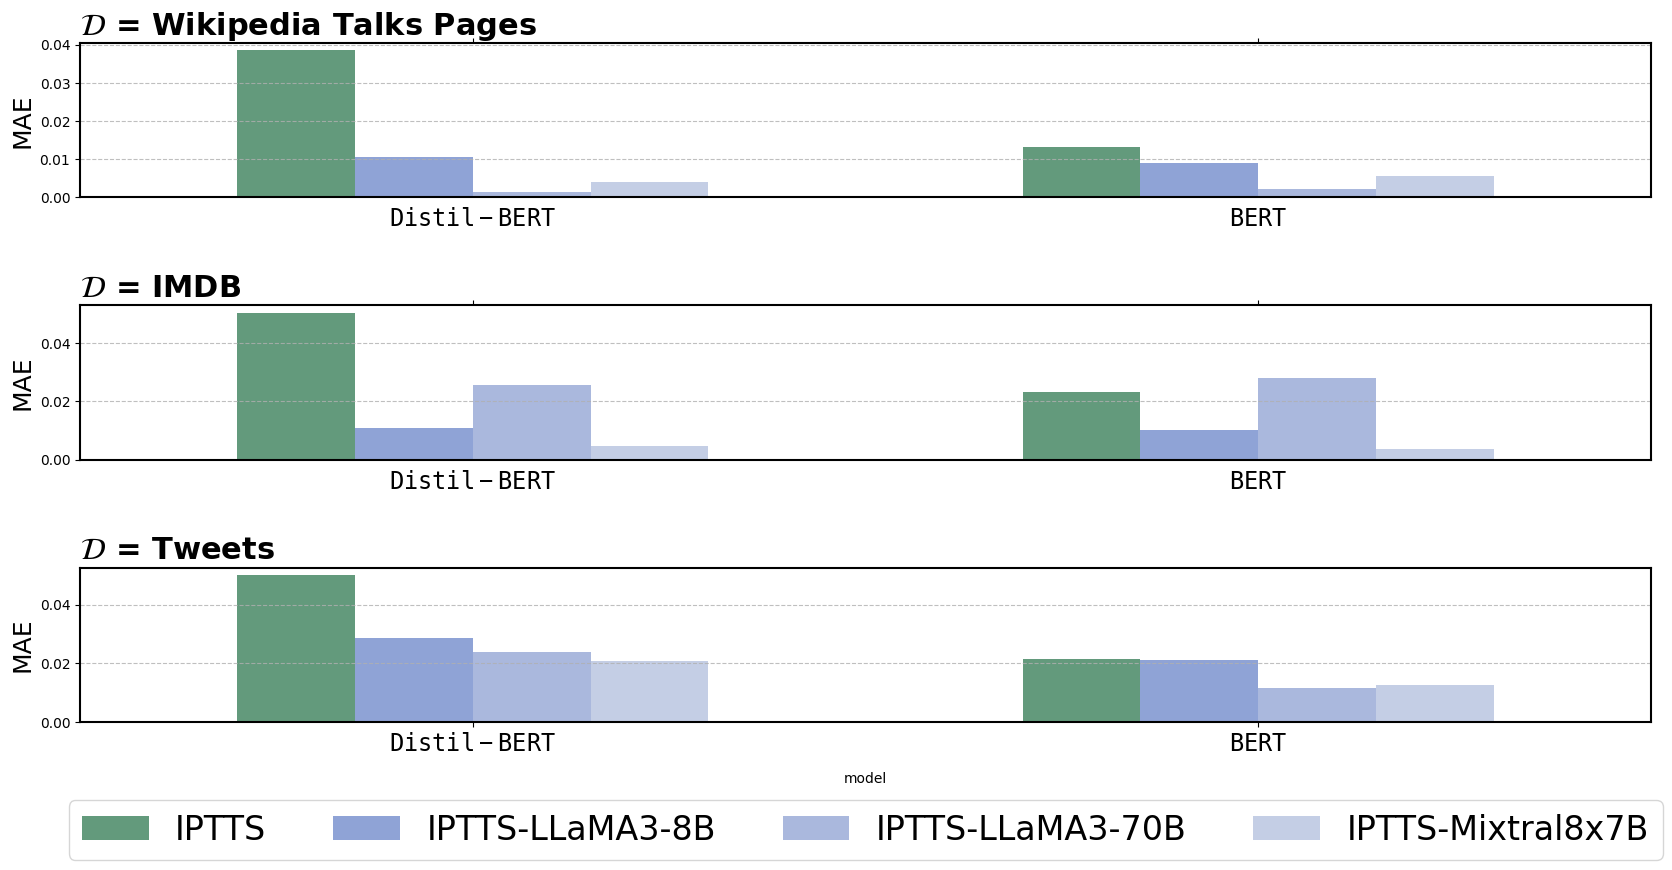

adaptation_llm/Scores/sum/initial/IPTTS_nationality_initial_Others.csv
adaptation_llm/Scores/sum/initial/IPTTS_nationality_initial_NOEs.csv


/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)
/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)
/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)


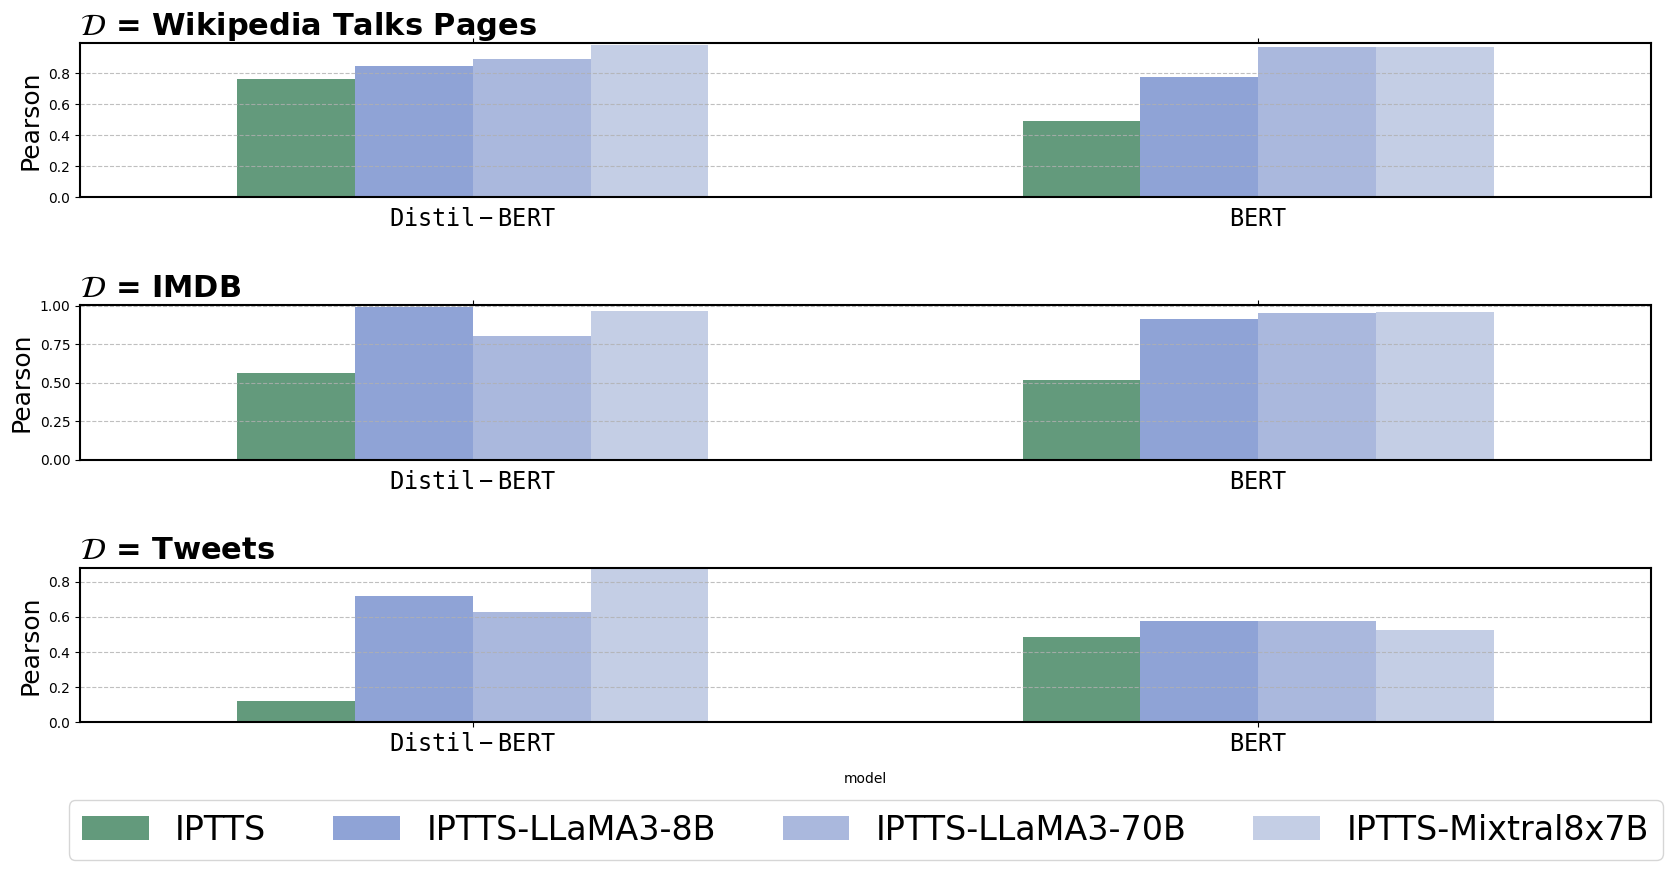

bert-base-cased
adaptation_llm/Scores/bert-base-cased/IPTTS/template/interseccion/scores_IPTTS.csv
adaptation_llm/Scores/bert-base-cased/IPTTS/LLMs/interseccion/scores_llama3_8_wikipedia_talks.csv
adaptation_llm/Scores/bert-base-cased/IPTTS/LLMs/interseccion/scores_llama3_8_IMDB.csv
adaptation_llm/Scores/bert-base-cased/IPTTS/LLMs/interseccion/scores_llama3_8_tweets.csv
adaptation_llm/Scores/bert-base-cased/IPTTS/LLMs/interseccion/scores_mixtral_wikipedia_talks.csv
adaptation_llm/Scores/bert-base-cased/IPTTS/LLMs/interseccion/scores_mixtral_IMDB.csv
adaptation_llm/Scores/bert-base-cased/IPTTS/LLMs/interseccion/scores_mixtral_tweets.csv
adaptation_llm/Scores/bert-base-cased/IPTTS/LLMs/interseccion/scores_llama3_70_wikipedia_talks.csv
adaptation_llm/Scores/bert-base-cased/IPTTS/LLMs/interseccion/scores_llama3_70_IMDB.csv
adaptation_llm/Scores/bert-base-cased/IPTTS/LLMs/interseccion/scores_llama3_70_tweets.csv
adaptation_llm/Scores/bert-base-cased/IPTTS/NOEs/interseccion/scores_wikipedia_

/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)
/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)
/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)


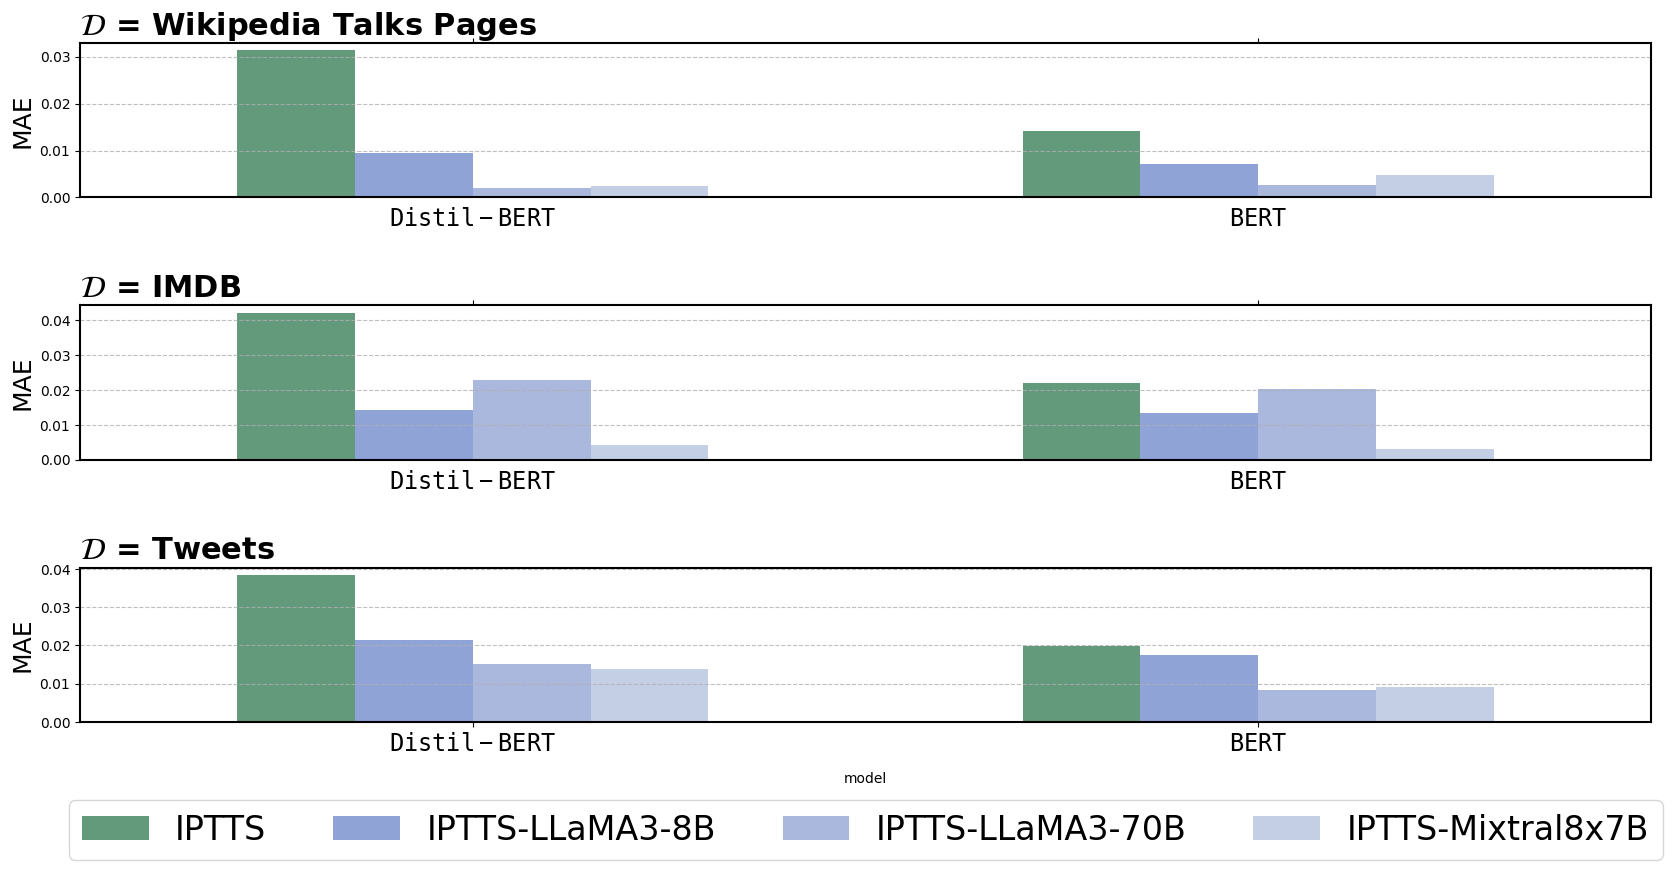

adaptation_llm/Scores/sum/initial/IPTTS_interseccion_initial_Others.csv
adaptation_llm/Scores/sum/initial/IPTTS_interseccion_initial_NOEs.csv


/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)
/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)
/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)


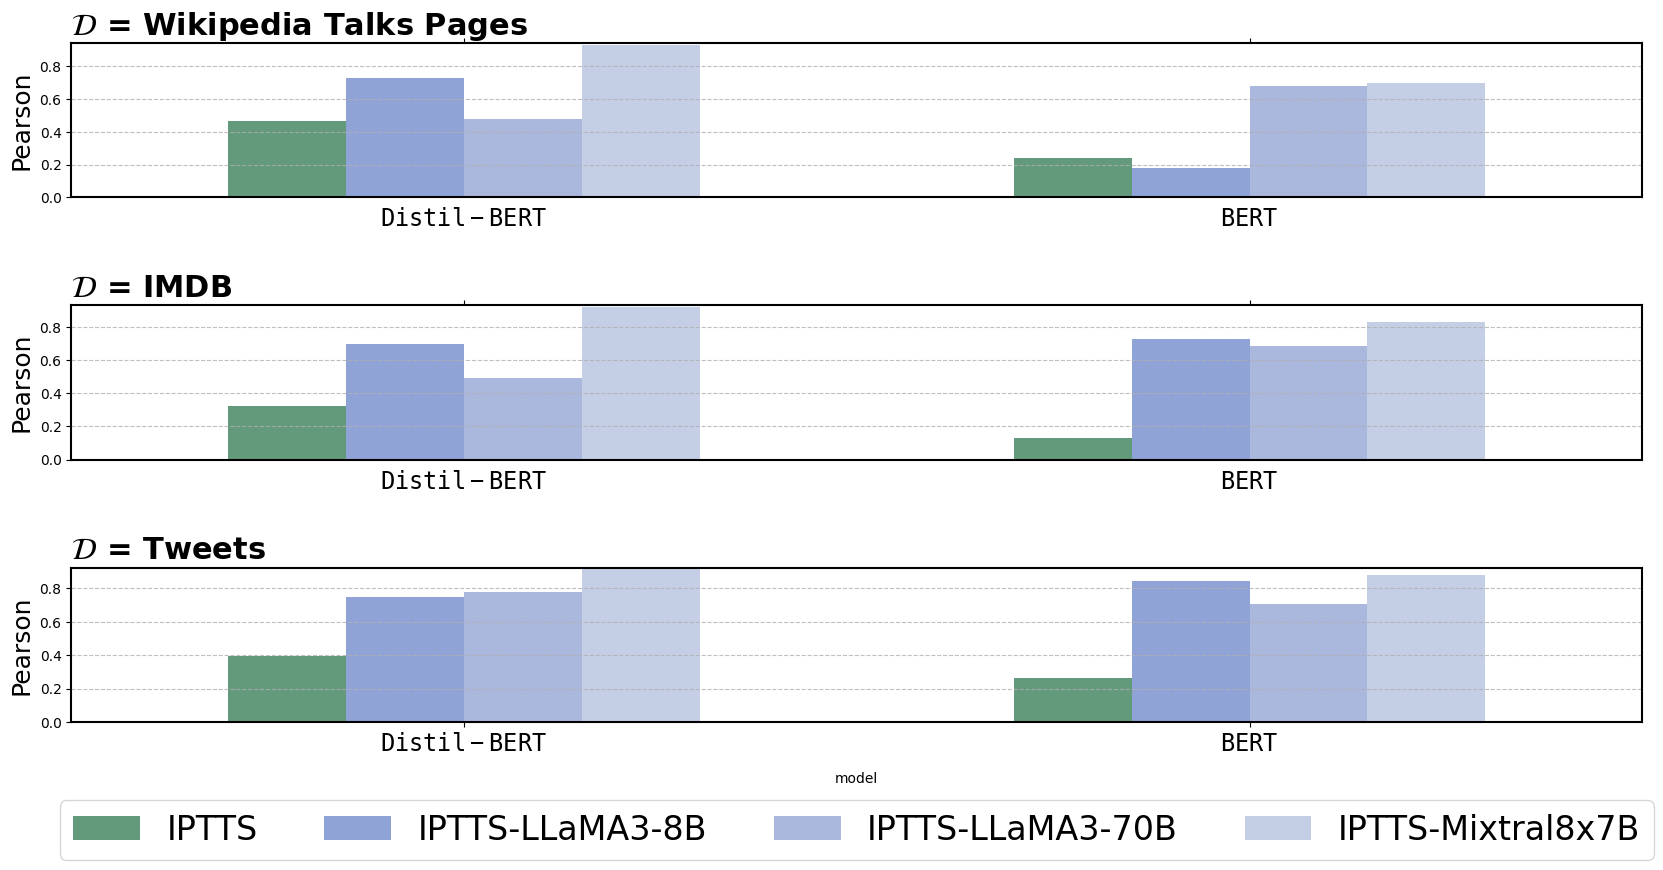

distilbert-distilbert-base-cased
adaptation_llm/Scores/distilbert-distilbert-base-cased/EEC/template/nationality/scores_EEC.csv
adaptation_llm/Scores/distilbert-distilbert-base-cased/EEC/LLMs/nationality/scores_llama3_8_wikipedia_talks.csv
adaptation_llm/Scores/distilbert-distilbert-base-cased/EEC/LLMs/nationality/scores_llama3_8_IMDB.csv
adaptation_llm/Scores/distilbert-distilbert-base-cased/EEC/LLMs/nationality/scores_llama3_8_tweets.csv
adaptation_llm/Scores/distilbert-distilbert-base-cased/EEC/LLMs/nationality/scores_mixtral_wikipedia_talks.csv
adaptation_llm/Scores/distilbert-distilbert-base-cased/EEC/LLMs/nationality/scores_mixtral_IMDB.csv
adaptation_llm/Scores/distilbert-distilbert-base-cased/EEC/LLMs/nationality/scores_mixtral_tweets.csv
adaptation_llm/Scores/distilbert-distilbert-base-cased/EEC/LLMs/nationality/scores_llama3_70_wikipedia_talks.csv
adaptation_llm/Scores/distilbert-distilbert-base-cased/EEC/LLMs/nationality/scores_llama3_70_IMDB.csv
adaptation_llm/Scores/distil

/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)
/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)
/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)


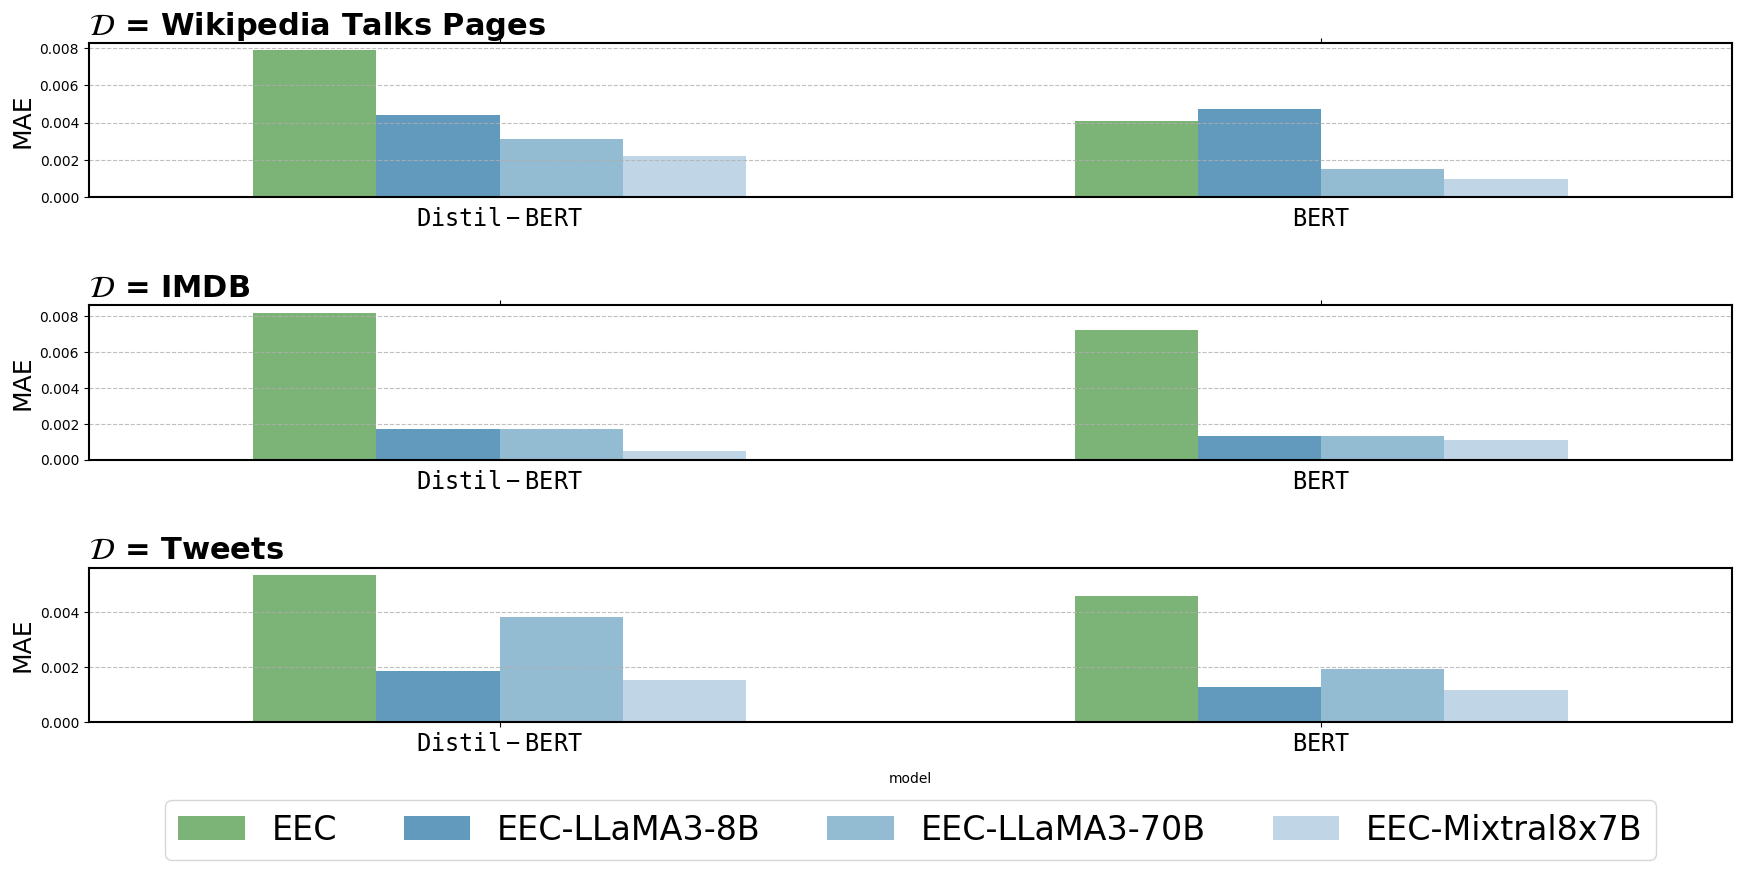

adaptation_llm/Scores/sum/initial/EEC_nationality_initial_Others.csv
adaptation_llm/Scores/sum/initial/EEC_nationality_initial_NOEs.csv


/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)
/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)
/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)


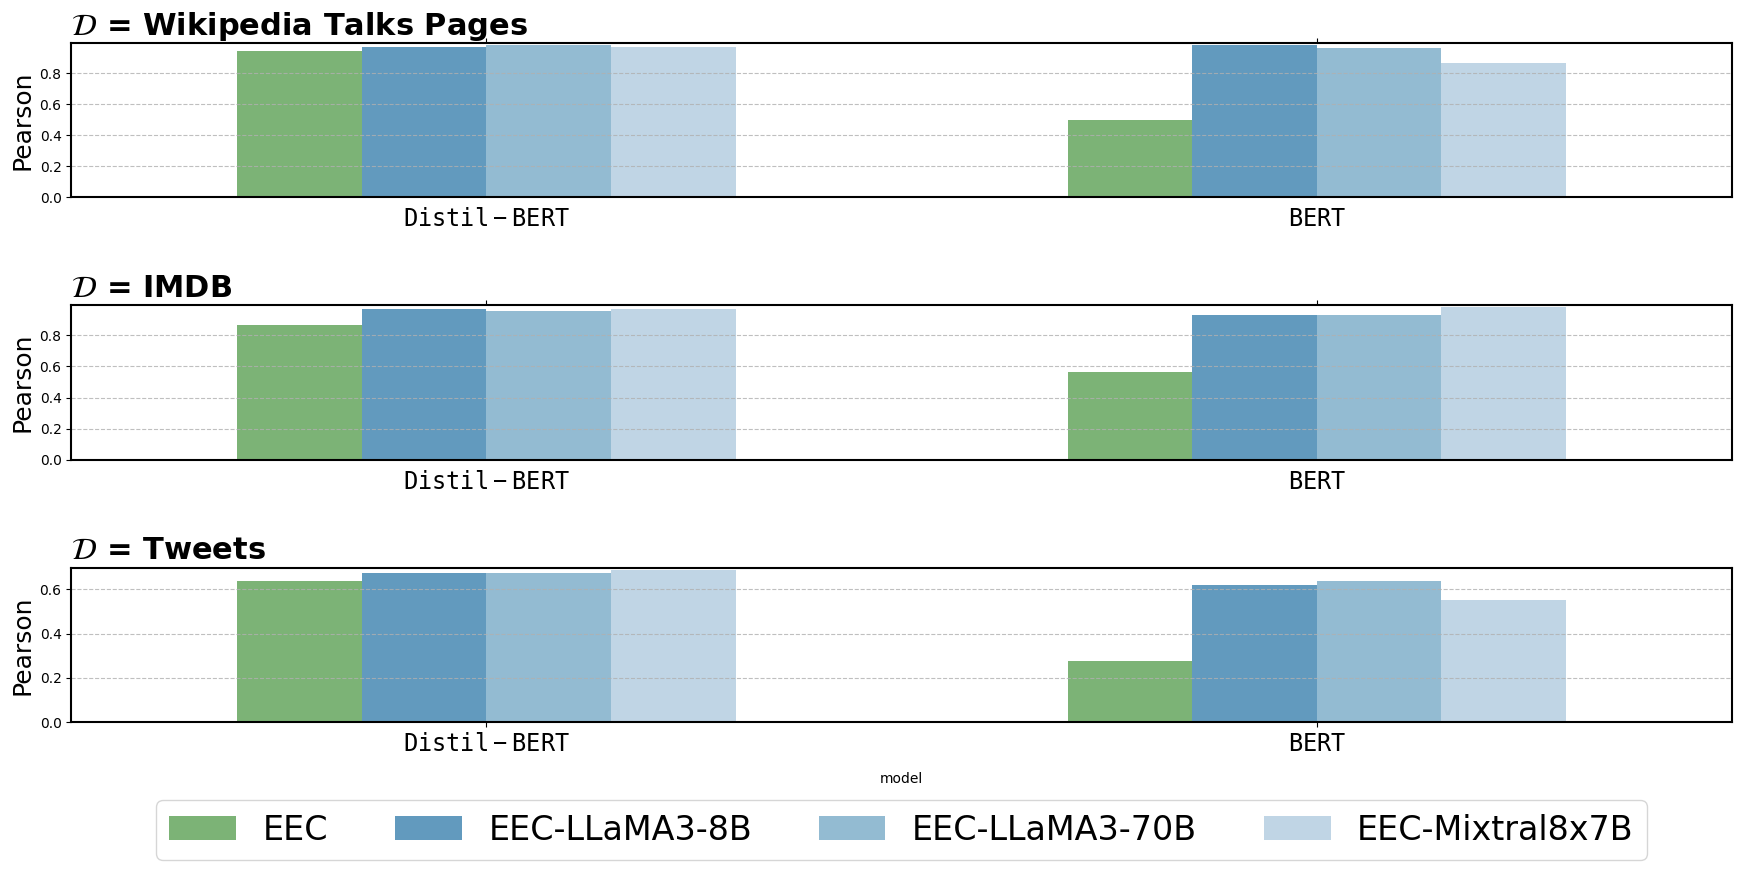

distilbert-distilbert-base-cased
adaptation_llm/Scores/distilbert-distilbert-base-cased/EEC/template/interseccion/scores_EEC.csv
adaptation_llm/Scores/distilbert-distilbert-base-cased/EEC/LLMs/interseccion/scores_llama3_8_wikipedia_talks.csv
adaptation_llm/Scores/distilbert-distilbert-base-cased/EEC/LLMs/interseccion/scores_llama3_8_IMDB.csv
adaptation_llm/Scores/distilbert-distilbert-base-cased/EEC/LLMs/interseccion/scores_llama3_8_tweets.csv
adaptation_llm/Scores/distilbert-distilbert-base-cased/EEC/LLMs/interseccion/scores_mixtral_wikipedia_talks.csv
adaptation_llm/Scores/distilbert-distilbert-base-cased/EEC/LLMs/interseccion/scores_mixtral_IMDB.csv
adaptation_llm/Scores/distilbert-distilbert-base-cased/EEC/LLMs/interseccion/scores_mixtral_tweets.csv
adaptation_llm/Scores/distilbert-distilbert-base-cased/EEC/LLMs/interseccion/scores_llama3_70_wikipedia_talks.csv
adaptation_llm/Scores/distilbert-distilbert-base-cased/EEC/LLMs/interseccion/scores_llama3_70_IMDB.csv
adaptation_llm/Scor

/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)
/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)
/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)


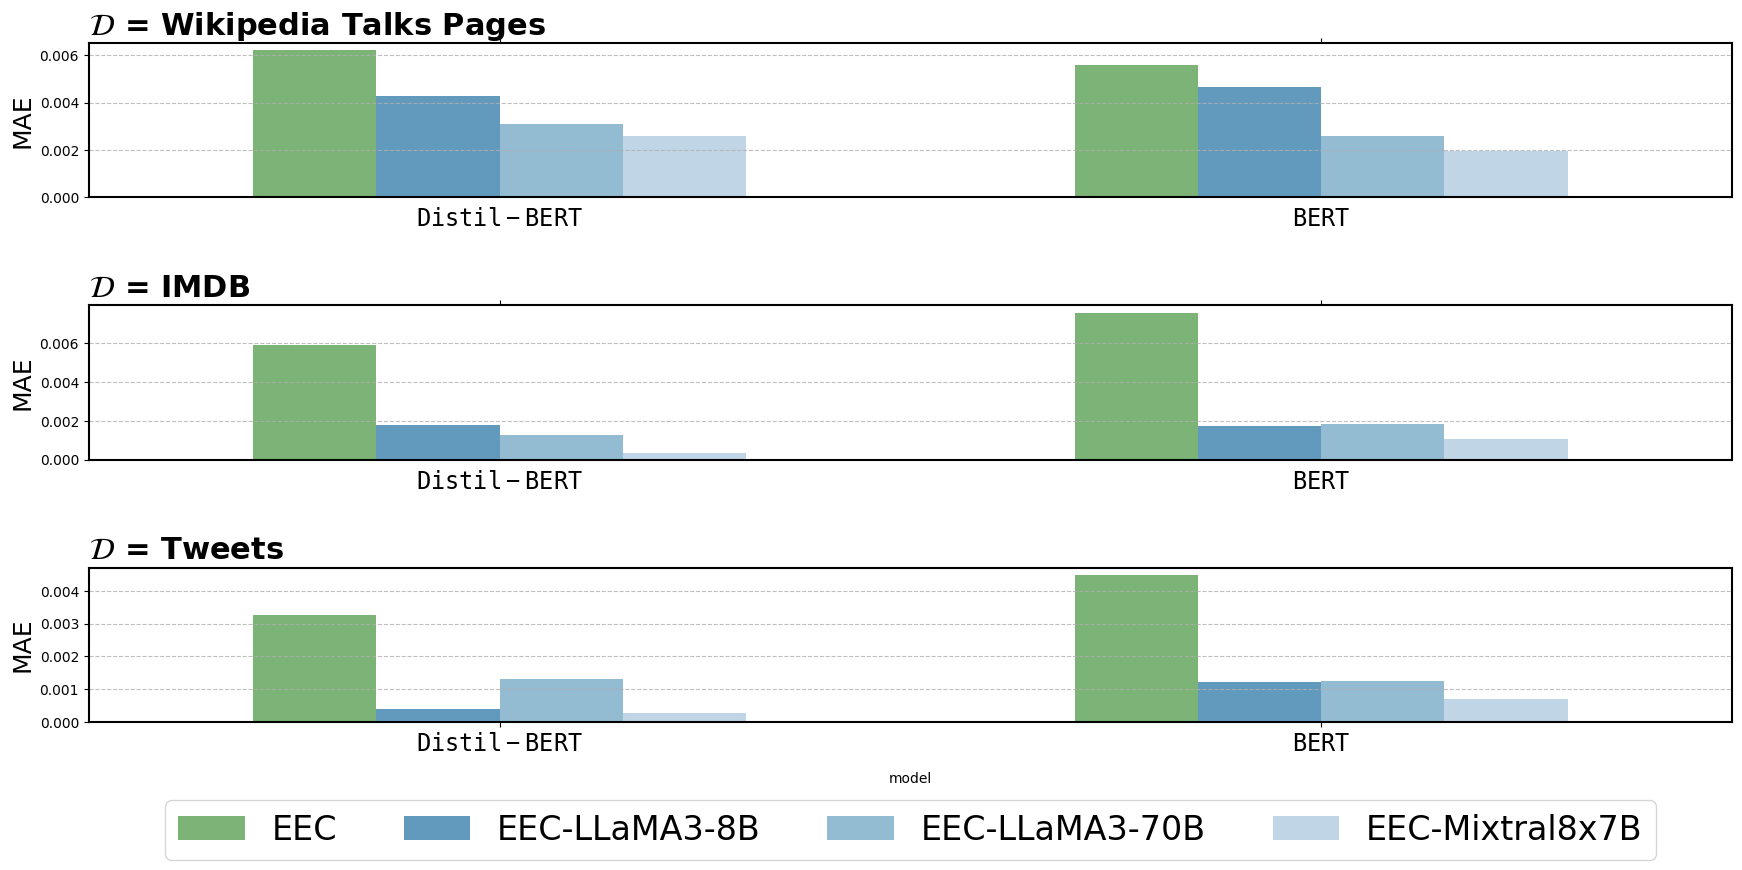

adaptation_llm/Scores/sum/initial/EEC_interseccion_initial_Others.csv
adaptation_llm/Scores/sum/initial/EEC_interseccion_initial_NOEs.csv


/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)
/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)
/tmp/ipykernel_619503/53221519.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(new_labels, rotation=0, fontsize=17)


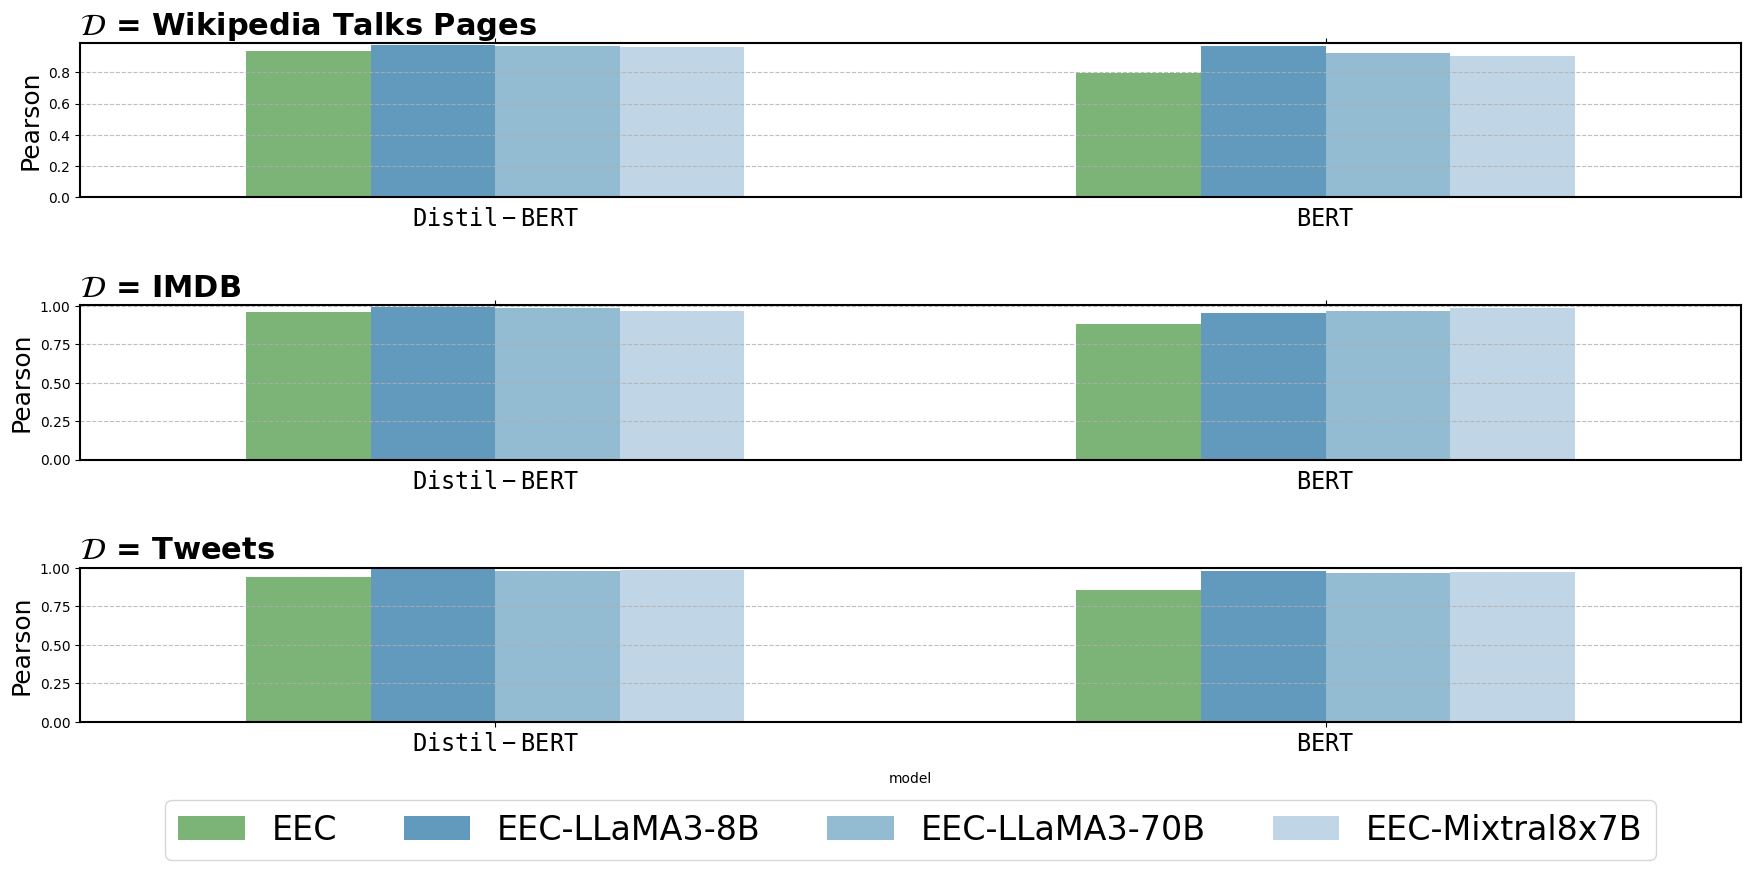

In [ ]:

dict_test_model = {"EEC":[
                        "distilbert-distilbert-base-cased",
                         "cardiffnlp-twitter-roberta-base", 
                        "bert-base-cased",
                        #   # "cardiffnlp-twitter-xlm-roberta-base",
                         "cardiffnlp-sentiment",
                        # "mistral",
                         "llama38B"
                        ],
                "IPTTS":[
                        #  "llama38B",
                         "llama38B_128",
                        # "llama38B",
                         "bert-base-cased",
                         "distilbert-distilbert-base-cased",
                      "cardiffnlp-hate",
                      # # "mistral",
                             "cardiffnlp-offensive",
                          #  "google-bert-bert-base-multilingual-cased",

                ]}


prompt = "f3"
name_experiment = "initial"
# name_experiment = "n5"

l_domains = ["wikipedia_talks","IMDB","tweets"]
l_models_llm = ["llama3_8","mixtral","llama3_70"] 

for template in ["IPTTS","EEC"]:
    for bias_type in ["nationality","interseccion"]:

        bias_cores = BiasScores(dict_test_model,l_domains,l_models_llm, prompt,template,name_experiment,bias_type)
        # bias_cores.VBCM_all_models(MCM= True)
        bias_cores.VBCM_all_models()

        print(bias_type,template)
        graph_biasMetric = PlotMetric(template, name_experiment, l_domains,l_models_llm,prompt,bias_type)
        df_metrics_sum = graph_biasMetric.table_sum()
        path = Path( f"/home/tquiroga/template_domain/graphs/{name_experiment}/")
        path.mkdir(parents=True, exist_ok=True)
        df_metrics_sum.to_csv( f"/home/tquiroga/template_domain/graphs/{name_experiment}/{template}_{bias_type}.csv" ,index=False)
        
        graph_biasMetric = PlotMetric(template, name_experiment, l_domains,l_models_llm,prompt,bias_type)
        df_metric = graph_biasMetric.calculation_df_metric_bias("MAE")
        graph_biasMetric.bar_graph("MAE")

        graph_biasMetric = PlotMetric(template, name_experiment, l_domains,l_models_llm,prompt,bias_type)
        df_metric = graph_biasMetric.calculation_df_metric_bias("Pearson")
        graph_biasMetric.bar_graph("Pearson")

In [ ]:
L = []
for template in ["IPTTS","EEC"]:
    for bias_type in ["interseccion","nationality"]:
        df_metrics_sum_old = pd.read_csv(f"graphs/test_NOEs_old/{template}_{bias_type}.csv")
        df_metrics_sum_old = df_metrics_sum_old.drop(columns=["wikipedia_talks"])
        df_metrics_sum_new = pd.read_csv(f"graphs/test_NOEs_new/{template}_{bias_type}.csv")
        df_metrics_sum_new = df_metrics_sum_new.drop(columns=["wikipedia_talks"])

        dif = df_metrics_sum_new.merge(df_metrics_sum_old, on =["metric","template_type","bias","dataset"], suffixes=("_new","_old"), how ="left")
        for var in ["IMDB","tweets"]:
            dif[f"dif_{var}"] =  dif[f"{var}_new"]- dif[f"{var}_old"]

        L.append(dif)

df_final = pd.concat(L, axis=0)
df_final.to_csv("tabla_chatgpt.csv", index=False)
df_final

,bias,dataset,metric,template_type,IMDB_new,tweets_new,IMDB_old,tweets_old,dif_IMDB,dif_tweets
0,interseccion,IPTTS,MAE,LLaMA3-70B,-0.011574,-0.013890,-0.011574,-0.013893,0.000000,0.000003
1,interseccion,IPTTS,MAE,LLaMA3-8B,-0.015576,-0.011066,-0.015252,-0.011056,-0.000324,-0.000010
2,interseccion,IPTTS,MAE,Mixtral8x7B,-0.021272,-0.013390,-0.020601,-0.013390,-0.000672,0.000000
3,interseccion,IPTTS,Pearson,LLaMA3-70B,0.180536,0.280483,0.072749,0.231108,0.107788,0.049375
4,interseccion,IPTTS,Pearson,LLaMA3-8B,0.396080,0.266079,0.066130,0.197983,0.329951,0.068096
5,interseccion,IPTTS,Pearson,Mixtral8x7B,0.377182,0.379622,0.000502,0.267962,0.376680,0.111660
0,nationality,IPTTS,MAE,LLaMA3-70B,-0.009133,-0.012886,-0.009093,-0.012972,-0.000040,0.000086
1,nationality,IPTTS,MAE,LLaMA3-8B,-0.017951,-0.010711,-0.015872,-0.010835,-0.002079,0.000124
2,nationality,IPTTS,MAE,Mixtral8x7B,-0.020581,-0.014152,-0.018479,-0.014242,-0.002102,0.000090
3,nationality,IPTTS,Pearson,LLaMA3-70B,0.194588,0.154891,0.053893,0.120824,0.140695,0.034067


In [53]:
dif

,bias,dataset,metric,template_type,IMDB_new,tweets_new,IMDB_old,tweets_old,dif_IMDB,dif_tweets
0,interseccion,EEC,MAE,LLaMA3-70B,-0.011631,-0.012890,-0.010498,-0.009320,-0.001133,-0.003570
1,interseccion,EEC,MAE,LLaMA3-8B,-0.011354,-0.013862,-0.010229,-0.011624,-0.001126,-0.002237
2,interseccion,EEC,MAE,Mixtral8x7B,-0.012378,-0.011017,-0.010620,-0.010802,-0.001759,-0.000215
3,interseccion,EEC,Pearson,LLaMA3-70B,0.147928,0.053336,0.119357,0.058936,0.028571,-0.005600
4,interseccion,EEC,Pearson,LLaMA3-8B,0.142178,0.168270,0.153553,0.161860,-0.011374,0.006410
5,interseccion,EEC,Pearson,Mixtral8x7B,0.131829,0.220743,0.209534,0.215558,-0.077705,0.005185


In [41]:
df_metrics_sum_new

,bias,dataset,metric,template_type,IMDB,tweets,wikipedia_talks
0,interseccion,EEC,MAE,LLaMA3-70B,-0.011631,-0.012890,-0.003056
1,interseccion,EEC,MAE,LLaMA3-8B,-0.011354,-0.013862,-0.001882
2,interseccion,EEC,MAE,Mixtral8x7B,-0.012378,-0.011017,-0.004511
3,interseccion,EEC,Pearson,LLaMA3-70B,0.147928,0.053336,0.099727
4,interseccion,EEC,Pearson,LLaMA3-8B,0.142178,0.168270,0.178808
5,interseccion,EEC,Pearson,Mixtral8x7B,0.131829,0.220743,0.182418


In [ ]:
L = []
for template in ["EEC","IPTTS"]:
    for bias_type in ["nationality","interseccion"]:
        df_mcm = pd.read_csv(f"adaptation_llm/Scores/sum/{template}_{bias_type}_MCM.csv")
        df_mcm["dataset"] = template
        df_mcm["bias"] = bias_type
        L.append(df_mcm)

df_mcm_complete = pd.concat(L, axis=0)
df_mcm_complete = df_mcm_complete[["dataset","bias","domain","model","template_type","f1"]]
df_mcm_complete = df_mcm_complete[["dataset","bias","domain","template_type","f1"]].groupby(["dataset","bias","domain","template_type"]).agg("mean").reset_index()
df_mcm_complete = df_mcm_complete.sort_values(by=["dataset","bias","domain"])
df_mcm_complete = df_mcm_complete.rename(columns={"f1":"std","dataset":"template"})
df_mcm_complete.to_csv(f"graphs/{name_experiment}/MCM_newdata.csv",index=False)

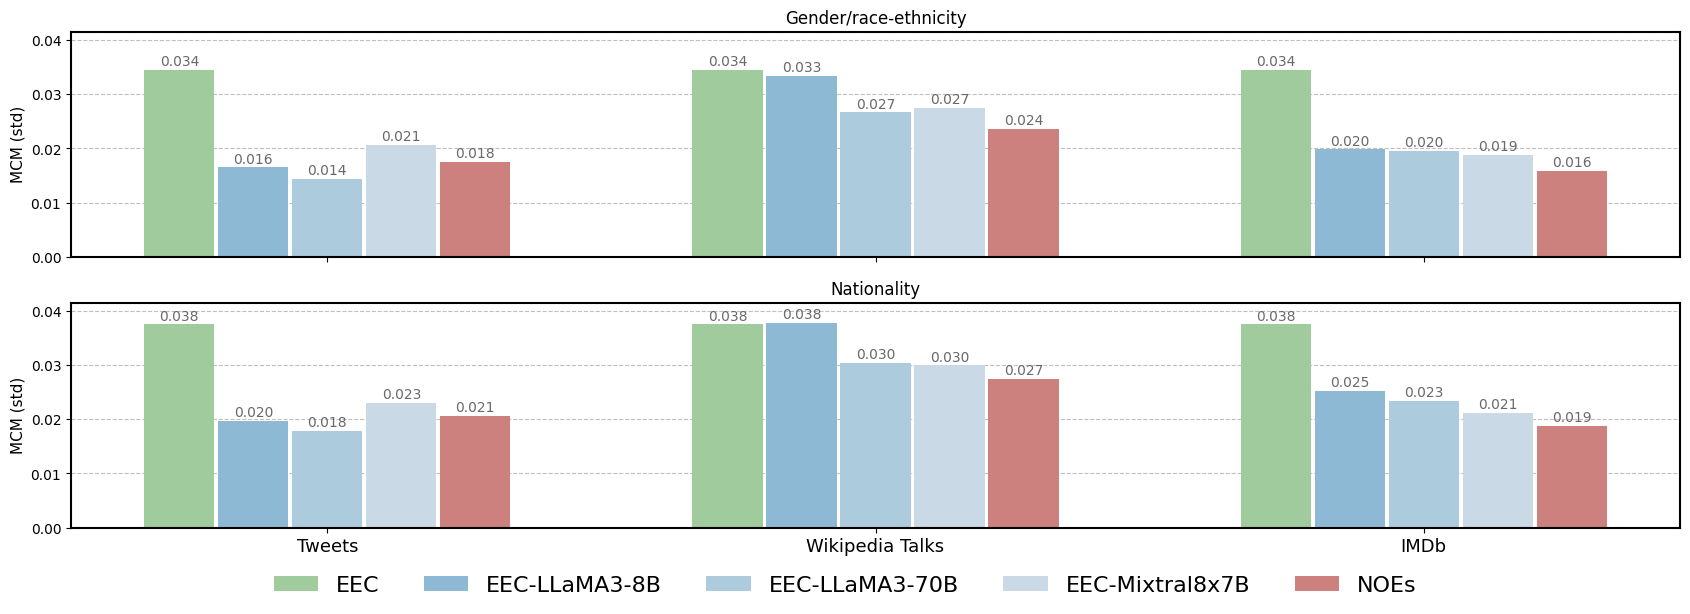

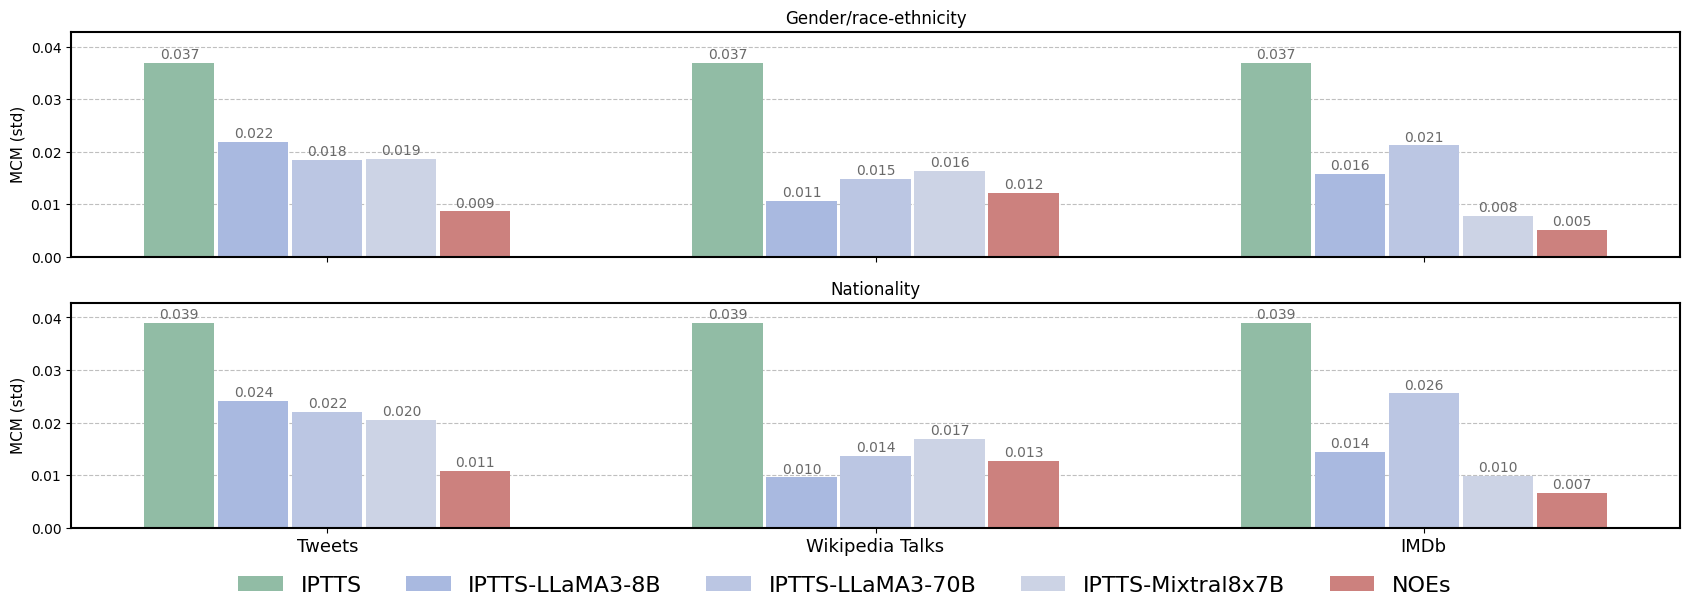

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

df = pd.read_csv("std_newdata.csv")
df["bias"] = df["bias"].apply(lambda x: x.replace("interseccion","Gender/Race-Ethnicity").capitalize())
df["domain"] = df["domain"].apply(lambda x: x.replace("wikipedia_talks","Wikipedia Talks").replace("tweets","Tweets").replace("IMDB","IMDb"))
df["template_type"] = df["template_type"].apply(lambda x: x.replace("wikipedia_talks","Wikipedia Talks").replace("tweets","Tweets").replace("IMDB","IMDb"))

# ==========
# COLORES BASE
# ==========

colors_by_template = {
    "IPTTS": {
        "template": "#5aa37b",
        "llama3_8": (0.5147431176410597, 0.6201634591747677, 0.8842039657367949),
        "llama3_70": (0.631611107831028, 0.708601550309562, 0.9020660296045181),
        "mixtral": (0.7484790980209962, 0.7970396414443562, 0.9199280934722412),
        "domain": "#bf3e38",
    },
    "EEC": {
        "template": "#74bd6c",
        "llama3_8": (0.32628988850442137, 0.6186236063052672, 0.802798923490965),
        "llama3_70": (0.5356862745098039, 0.746082276047674, 0.8642522106881968),
        "mixtral": (0.7309496347558632, 0.8394771241830065, 0.9213225682429834),
        "domain": "#bf3e38",
    }
}

# ==========
# FUNCIONES
# ==========

def lighten_color(color, amount=0.42):
    rgb = mcolors.to_rgb(color)
    white = (0.87, 0.87, 0.87)
    return tuple((1 - amount) * c + amount * w for c, w in zip(rgb, white))

def get_order(template, domain):
    return [template, "llama3_8", "llama3_70", "mixtral", domain]

def get_color_map(template, domain, lighten_amount=0.42):
    palette = colors_by_template[template]
    return {
        template: lighten_color(palette["template"], lighten_amount),
        "llama3_8": lighten_color(palette["llama3_8"], lighten_amount),
        "llama3_70": lighten_color(palette["llama3_70"], lighten_amount),
        "mixtral": lighten_color(palette["mixtral"], lighten_amount),
        domain: lighten_color(palette["domain"], lighten_amount)
    }

# ==========
# ORDEN FIJO
# ==========

templates = ["EEC", "IPTTS"]
biases = list(df["bias"].unique())
domains = ["Tweets", "Wikipedia Talks", "IMDb"]

# ==========
# GRAFICAR
# ==========

for template in templates:
    df_template = df[df["template"] == template].copy()

    biases_present = [b for b in biases if b in df_template["bias"].unique()]
    domains_present = [d for d in domains if d in df_template["domain"].unique()]

    fig, axes = plt.subplots(
        nrows=len(biases_present),
        ncols=1,
        figsize=(17, 3.2 * len(biases_present)),
        sharex=True,
        sharey=False
    )

    axes = np.atleast_1d(axes)

    for i, bias in enumerate(biases_present):
        ax = axes[i]

        # posiciones base de cada dominio en el eje x
        x = np.arange(len(domains_present))

        # ancho de cada barra
        width = 0.135

        # offsets para las 5 barras dentro de cada dominio
        offsets = {
            "template": -2 * width,
            "llama3_8": -1 * width,
            "llama3_70": 0,
            "mixtral": 1 * width,
            "domain": 2 * width
        }

        # guardar para leyenda
        legend_colors = None

        for domain in domains_present:
            subdf = df_template[
                (df_template["bias"] == bias) &
                (df_template["domain"] == domain)
            ].copy()

            if subdf.empty:
                continue

            order = get_order(template, domain)
            order_present = [x_ for x_ in order if x_ in subdf["template_type"].values]

            subdf["template_type"] = pd.Categorical(
                subdf["template_type"],
                categories=order_present,
                ordered=True
            )
            subdf = subdf.sort_values("template_type")

            color_map = get_color_map(template, domain, lighten_amount=0.42)
            legend_colors = color_map

            domain_idx = domains_present.index(domain)

            for _, row in subdf.iterrows():
                tt = row["template_type"]

                if tt == template:
                    group = "template"
                elif tt in ["llama3_8", "llama3_70", "mixtral"]:
                    group = tt
                elif tt == domain:
                    group = "domain"
                else:
                    continue

                xpos = x[domain_idx] + offsets[group]

                ax.bar(
                    xpos,
                    row["std"],
                    width=width * 0.95,
                    color=color_map[tt],
                    edgecolor="none"
                )

                ax.text(
                    xpos,
                    row["std"] + max(subdf["std"]) * 0.008,
                    f"{row['std']:.3f}",
                    ha="center",
                    va="bottom",
                    fontsize=10,
                    color="dimgray"
                )

        ax.set_title(f"{bias}", fontsize=12)
        ax.set_ylabel("MCM (std)", fontsize=11)
        ax.set_xticks(x)
        ax.set_xticklabels(domains_present, fontsize=13)

        # ===== EFECTOS VISUALES =====
        ax.grid(True, linestyle='--', axis='y', alpha=0.8)
        ax.set_axisbelow(True)
        value_bacan = df[df["template"]==template]["std"].max()
        ax.set_ylim(0, value_bacan*1.1)  # <- ajusta este rango según tus datos

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.5)
            spine.set_color("black")

    # leyenda única
    handles = [
        Patch(facecolor=legend_colors[template], label=template),
        Patch(facecolor=legend_colors["llama3_8"], label=template+"-LLaMA3-8B"),
        Patch(facecolor=legend_colors["llama3_70"], label=template+"-LLaMA3-70B"),
        Patch(facecolor=legend_colors["mixtral"], label=template+"-Mixtral8x7B"),
        Patch(facecolor=legend_colors[[*legend_colors][-1]], label="NOEs")
    ]

    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=5,
        frameon=False,
        bbox_to_anchor=(0.5, -0.01),
        fontsize=16
    )

    # fig.suptitle(f"Template = {template}", fontsize=16, y=0.98)

    plt.tight_layout(rect=[0, 0.06, 1, 0.96])
    plt.savefig(f"graphs/MCM_{template}.pdf",  bbox_inches='tight')
    plt.show()

In [ ]:
df_metrics_sum_interseccion = pd.read_csv(f"graphs/{name_experiment}/{template}_interseccion.csv")
df_metrics_sum_interseccion

,bias,dataset,metric,template_type,IMDB,tweets,wikipedia_talks
0,interseccion,IPTTS,MAE,LLaMA3-70B,-0.011574,-0.013890,-0.014184
1,interseccion,IPTTS,MAE,LLaMA3-8B,-0.015576,-0.011066,-0.012627
2,interseccion,IPTTS,MAE,Mixtral8x7B,-0.021272,-0.013390,-0.014946
3,interseccion,IPTTS,Pearson,LLaMA3-70B,0.180536,0.280483,0.176822
4,interseccion,IPTTS,Pearson,LLaMA3-8B,0.396080,0.266079,0.078834
5,interseccion,IPTTS,Pearson,Mixtral8x7B,0.377182,0.379622,0.263876


In [ ]:
df_metrics_sum_nationality = pd.read_csv(f"graphs/{name_experiment}/{template}_nationality.csv")
df_metrics_sum_nationality

,bias,dataset,metric,template_type,IMDB,tweets,wikipedia_talks
0,nationality,IPTTS,MAE,LLaMA3-70B,-0.009133,-0.012886,-0.016638
1,nationality,IPTTS,MAE,LLaMA3-8B,-0.017951,-0.010711,-0.013059
2,nationality,IPTTS,MAE,Mixtral8x7B,-0.020581,-0.014152,-0.015506
3,nationality,IPTTS,Pearson,LLaMA3-70B,0.194588,0.154891,0.142648
4,nationality,IPTTS,Pearson,LLaMA3-8B,0.205648,0.199081,0.075386
5,nationality,IPTTS,Pearson,Mixtral8x7B,0.226937,0.188402,0.118997


In [10]:
df_LLMs_Templates = pd.read_csv("adaptation_llm/Scores/sum/n5/EEC_nationality_n5_NOEs.csv")
df_LLMs_Templates["template_type"] = df_LLMs_Templates["template_type"].apply(lambda x: x.replace("IMBD","IMDB"))
df_LLMs_Templates["domain"] = df_LLMs_Templates["domain"].apply(lambda x: x.replace("IMBD","IMDB"))

df_NOEs = pd.read_csv("adaptation_llm/Scores/sum/n5/EEC_nationality_n5_Others.csv")
df_NOEs["template_type"] = df_NOEs["template_type"].apply(lambda x: x.replace("IMBD","IMDB"))
df_NOEs["domain"] = df_NOEs["domain"].apply(lambda x: x.replace("IMBD","IMDB"))
var = "MAE"
df_LLMs_Templates = df_LLMs_Templates.merge(df_NOEs, on =["domain","model","group"],how="left",suffixes=("","_NOEs")) 
if var == "MAE":
    df_LLMs_Templates[var] =df_LLMs_Templates.apply(lambda x : abs(x["DP"]-x["DP_NOEs"]), axis=1)
elif var =="Pearson":
    df_LLMs_Templates = df_LLMs_Templates.groupby(["domain","model","template_type"])['DP'].corr(df_LLMs_Templates['DP_NOEs']).reset_index()
    df_LLMs_Templates = df_LLMs_Templates.rename(columns={"DP":"Pearson"})
else:
    print("var can be MAE or Pearson")


df_metric_bias = df_LLMs_Templates.groupby(["domain","model","template_type"])[var].mean().reset_index()
dict_metric_bias= {}
for domain_ in l_domains:
    df_sum_i=df_metric_bias[df_metric_bias["domain"]==domain_].reset_index(drop=True)
    df_sum_i = df_sum_i.rename(columns={var:var+"_"+domain_}).drop(columns=["domain"])
    dict_metric_bias[domain_] = df_sum_i

df_metric_bias = dict_metric_bias[l_domains[0]]
for i in range(len(l_domains[1:])):
    df_metric_bias = df_metric_bias.merge(dict_metric_bias[l_domains[1:][i]],on=["model"],how="inner")
    {"llama3_70":"LLaMa3-70B","llama3_8":"LLaMa3-8B","mixtral": "Mixtral8x7B"}
df_metric_bias["template_type"] = df_metric_bias["template_type"].apply(lambda x: x.replace(f"llama3_70",f"{template}-LLaMA3-70B").
                                                                        replace(f"llama3_8",f"{template}-LLaMA3-8B").
                                                                        replace(f"mixtral",f"{template}-Mixtral8x7B"))

df_metric_bias

,model,template_type_x,MAE_wikipedia_talks,template_type_y,MAE_IMDB,template_type,MAE_tweets
0,BERT,wikipedia_talks,0.001825,IMDB,0.003155,tweets,0.001919
1,cardiffnlp-roberta,wikipedia_talks,0.006308,IMDB,0.004449,tweets,0.004418
2,distil-BERT,wikipedia_talks,0.003852,IMDB,0.003441,tweets,0.002565


In [ ]:
dict_metric_bias

{'tweets':                   model template_type  MAE_tweets
 0                  BERT        tweets    0.001919
 1  cardiffnlp-sentiment        tweets    0.001868
 2           distil-BERT        tweets    0.002565,
 'wikipedia_talks':                   model    template_type  MAE_wikipedia_talks
 0                  BERT  wikipedia_talks             0.001825
 1  cardiffnlp-sentiment  wikipedia_talks             0.005235
 2           distil-BERT  wikipedia_talks             0.003852,
 'IMDB':                   model template_type  MAE_IMDB
 0                  BERT          IMDB  0.002665
 1  cardiffnlp-sentiment          IMDB  0.003008
 2           distil-BERT          IMDB  0.002782}

In [11]:
df_LLMs_Templates = pd.read_csv("adaptation_llm/Scores/sum/n5/EEC_nationality_n5_NOEs.csv")
df_NOEs = pd.read_csv("adaptation_llm/Scores/sum/n5/EEC_nationality_n5_Others.csv")
var = "MAE"
df_LLMs_Templates = df_LLMs_Templates.merge(df_NOEs, on =["domain","model","group"],how="left",suffixes=("","_NOEs")) 
if var == "MAE":
    df_LLMs_Templates[var] =df_LLMs_Templates.apply(lambda x : abs(x["DP"]-x["DP_NOEs"]), axis=1)
elif var =="Pearson":
    df_LLMs_Templates = df_LLMs_Templates.groupby(["domain","model","template_type"])['DP'].corr(df_LLMs_Templates['DP_NOEs']).reset_index()
    df_LLMs_Templates = df_LLMs_Templates.rename(columns={"DP":"Pearson"})
else:
    print("var can be MAE or Pearson")

df_metric_bias = df_LLMs_Templates.groupby(["domain","model","template_type"])[var].mean().reset_index()

df_metric_bias

,domain,model,template_type,MAE
0,IMDB,BERT,IMDB,0.003155
1,IMDB,cardiffnlp-roberta,IMDB,0.004449
2,IMDB,distil-BERT,IMDB,0.003441
3,tweets,BERT,tweets,0.001919
4,tweets,cardiffnlp-roberta,tweets,0.004418
5,tweets,distil-BERT,tweets,0.002565
6,wikipedia_talks,BERT,wikipedia_talks,0.001825
7,wikipedia_talks,cardiffnlp-roberta,wikipedia_talks,0.006308
8,wikipedia_talks,distil-BERT,wikipedia_talks,0.003852


In [ ]:
domain_

'IMDB'

In [ ]:
dict_metric_bias= {}
for domain_ in self.l_domains:
    df_sum_i=df_metric_bias[df_metric_bias["domain"]==domain_].reset_index(drop=True)
    df_sum_i = df_sum_i.rename(columns={var:var+"_"+domain_}).drop(columns=["domain"])
    dict_metric_bias[domain_] = df_sum_i

df_metric_bias = dict_metric_bias[self.l_domains[0]]
for i in range(len(self.l_domains[1:])):
    df_metric_bias = df_metric_bias.merge(dict_metric_bias[self.l_domains[1:][i]],on=["model","template_type"],how="inner")
    {"llama3_70":"LLaMa3-70B","llama3_8":"LLaMa3-8B","mixtral": "Mixtral8x7B"}
df_metric_bias["template_type"] = df_metric_bias["template_type"].apply(lambda x: x.replace(f"llama3_70",f"{self.template}-LLaMA3-70B").
                                                                        replace(f"llama3_8",f"{self.template}-LLaMA3-8B").
                                                                        replace(f"mixtral",f"{self.template}-Mixtral8x7B"))
self.df_metric_bias = df_metric_bias

In [ ]:
        df_LLMs_Templates = pd.read_csv(f"adaptation_llm/Scores/sum/{self.name_experiment}/{self.template}_{self.bias_type}_{self.name_experiment}_Others.csv")
        df_NOEs = pd.read_csv(f"adaptation_llm/Scores/sum/{self.name_experiment}/{self.template}_{self.bias_type}_{self.name_experiment}_NOEs.csv")
        print(f"adaptation_llm/Scores/sum/{self.name_experiment}/{self.template}_{self.bias_type}_{self.name_experiment}_Others.csv")
        print(f"adaptation_llm/Scores/sum/{self.name_experiment}/{self.template}_{self.bias_type}_{self.name_experiment}_NOEs.csv")

        df_LLMs_Templates = df_LLMs_Templates.merge(df_NOEs, on =["domain","model","group"],how="left",suffixes=("","_NOEs")) 
        if var == "MAE":
            df_LLMs_Templates[var] =df_LLMs_Templates.apply(lambda x : abs(x["DP"]-x["DP_NOEs"]), axis=1)
        elif var =="Pearson":
            df_LLMs_Templates = df_LLMs_Templates.groupby(["domain","model","template_type"])['DP'].corr(df_LLMs_Templates['DP_NOEs']).reset_index()
            df_LLMs_Templates = df_LLMs_Templates.rename(columns={"DP":"Pearson"})
        else:
            print("var can be MAE or Pearson")
        
        df_metric_bias = df_LLMs_Templates.groupby(["domain","model","template_type"])[var].mean().reset_index()
        dict_metric_bias= {}
        for domain_ in self.l_domains:
            df_sum_i=df_metric_bias[df_metric_bias["domain"]==domain_].reset_index(drop=True)
            df_sum_i = df_sum_i.rename(columns={var:var+"_"+domain_}).drop(columns=["domain"])
            dict_metric_bias[domain_] = df_sum_i

        df_metric_bias = dict_metric_bias[self.l_domains[0]]
        for i in range(len(self.l_domains[1:])):
            df_metric_bias = df_metric_bias.merge(dict_metric_bias[self.l_domains[1:][i]],on=["model","template_type"],how="inner")
            {"llama3_70":"LLaMa3-70B","llama3_8":"LLaMa3-8B","mixtral": "Mixtral8x7B"}
        df_metric_bias["template_type"] = df_metric_bias["template_type"].apply(lambda x: x.replace(f"llama3_70",f"{self.template}-LLaMA3-70B").
                                                                                replace(f"llama3_8",f"{self.template}-LLaMA3-8B").
                                                                                replace(f"mixtral",f"{self.template}-Mixtral8x7B"))
        self.df_metric_bias = df_metric_bias
        return self.df_metric_bias

In [19]:
df_metric

,model,template_type,MAE_tweets,MAE_wikipedia_talks,MAE_IMDB


In [13]:
prompt = "f3"
name_experiment = "random_IMDB"

l_domains = ["tweets","wikipedia_talks","IMDB"]
l_models_llm = ["llama3_8","mixtral","llama3_70"] 

dict_test_model = {"EEC":[
                        "distilbert-distilbert-base-cased",
                        "bert-base-cased",
                         "cardiffnlp-twitter-xlm-roberta-base",
                         "cardiffnlp-twitter-roberta-base", 
                        "cardiffnlp-sentiment"
                        ],
                "IPTTS":[
                        #  "llama38B",
                         "bert-base-cased",
                         "distilbert-distilbert-base-cased",
                         "cardiffnlp-hate",
                         "cardiffnlp-offensive",
                         "google-bert-bert-base-multilingual-cased",

                ]}
L = []
for bias_type in ["nationality","interseccion"]:

        for template in ["EEC","IPTTS"]:

                print(bias_type)
                graph_biasMetric = PlotMetric(template, name_experiment, l_domains,l_models_llm,prompt,bias_type)
                df_metrics_sum = graph_biasMetric.table_sum()

                L.append(df_metrics_sum)

df_new = pd.concat(L,axis=0)
df_new = df_new.sort_values(by=["bias","dataset","metric","template_type"],ascending=False)
df_new

df_new.to_csv("final_table.csv",index=True)

nationality
adaptation_llm/Scores/sum/random_IMDB/EEC_nationality_random_IMDB_Others.csv
adaptation_llm/Scores/sum/random_IMDB/EEC_nationality_random_IMDB_NOEs.csv
adaptation_llm/Scores/sum/random_IMDB/EEC_nationality_random_IMDB_Others.csv
adaptation_llm/Scores/sum/random_IMDB/EEC_nationality_random_IMDB_NOEs.csv
nationality
adaptation_llm/Scores/sum/random_IMDB/IPTTS_nationality_random_IMDB_Others.csv
adaptation_llm/Scores/sum/random_IMDB/IPTTS_nationality_random_IMDB_NOEs.csv
adaptation_llm/Scores/sum/random_IMDB/IPTTS_nationality_random_IMDB_Others.csv
adaptation_llm/Scores/sum/random_IMDB/IPTTS_nationality_random_IMDB_NOEs.csv
interseccion
adaptation_llm/Scores/sum/random_IMDB/EEC_interseccion_random_IMDB_Others.csv
adaptation_llm/Scores/sum/random_IMDB/EEC_interseccion_random_IMDB_NOEs.csv
adaptation_llm/Scores/sum/random_IMDB/EEC_interseccion_random_IMDB_Others.csv
adaptation_llm/Scores/sum/random_IMDB/EEC_interseccion_random_IMDB_NOEs.csv
interseccion
adaptation_llm/Scores/sum/

In [14]:
df_new_EEC = df_new[df_new["dataset"]=="EEC"].drop(columns = ["dataset"])
df_new_IPTTS = df_new[df_new["dataset"]=="IPTTS"].drop(columns = ["dataset"])

df_toatal = df_new_EEC.merge(df_new_IPTTS, on = ["bias","metric","template_type"],how="left",suffixes=("_EEC","_IPTTS"))
df_toatal = df_toatal.sort_values(by = ["bias","metric","template_type"], ascending=[False,True,False])
df_toatal["mean_EEC"] = df_toatal.apply(lambda x : sum([x[var] for var in df_toatal.columns if "EEC" in var])/3,axis=1)
df_toatal["mean_IPTTS"] = df_toatal.apply(lambda x : sum([x[var] for var in df_toatal.columns if "IPTTS" in var])/3,axis=1)

df_toatal[["bias","metric","template_type","tweets_EEC","wikipedia_talks_EEC","IMDB_EEC","mean_EEC","tweets_IPTTS","wikipedia_talks_IPTTS","IMDB_IPTTS","mean_IPTTS"]]

,bias,metric,template_type,tweets_EEC,wikipedia_talks_EEC,IMDB_EEC,mean_EEC,tweets_IPTTS,wikipedia_talks_IPTTS,IMDB_IPTTS,mean_IPTTS
3,nationality,MAE,Mixtral8x7B,0.010763,0.004003,0.012469,0.009078,0.014242,0.015506,0.020581,0.016776
4,nationality,MAE,LLaMA3-8B,0.011566,0.002130,0.009611,0.007769,0.010835,0.013059,0.017951,0.013948
5,nationality,MAE,LLaMA3-70B,0.010369,0.002922,0.010988,0.008093,0.012972,0.016638,0.011134,0.013582
0,nationality,Pearson,Mixtral8x7B,0.135267,0.164395,0.178597,0.159420,0.227191,0.168473,0.226937,0.207534
1,nationality,Pearson,LLaMA3-8B,0.131479,0.222709,0.146713,0.166967,0.171358,0.113085,0.205648,0.163364
2,nationality,Pearson,LLaMA3-70B,0.108045,0.177984,0.165529,0.150519,0.191308,0.146681,0.194588,0.177526
9,interseccion,MAE,Mixtral8x7B,0.010802,0.004511,0.012379,0.009231,0.013390,0.014946,0.021272,0.016536
10,interseccion,MAE,LLaMA3-8B,0.011983,0.002122,0.011355,0.008486,0.011056,0.012627,0.015576,0.013086
11,interseccion,MAE,LLaMA3-70B,0.011577,0.003056,0.011632,0.008755,0.013893,0.014184,0.011574,0.013217
6,interseccion,Pearson,Mixtral8x7B,0.244430,0.183023,0.131829,0.186427,0.268566,0.309972,0.379044,0.319194


In [ ]:
df_dif = df_new.merge(pd.read_csv("sum_initial.csv"),how="left",on=["bias","dataset","metric","template_type"],suffixes=("","_old"))
df_dif = df_dif[["bias","dataset","metric","template_type","IMDB","IMDB_old"]]
df_dif["dif"] = df_dif["IMDB"]-df_dif["IMDB_old"]

L_dataset = []
dataset = "IPTTS"
for dataset in ["IPTTS","EEC"]:
    df_dif_IPTTS = df_dif[df_dif["dataset"]==dataset]
    df_dif_IPTTS = df_dif_IPTTS.rename(columns={"IMDB":f"IMDB_{dataset}",
                                                "IMDB_old":f"IMDB_old_{dataset}",
                                                "dif":f"dif_{dataset}"})
    L_dataset.append(df_dif_IPTTS.drop(columns=["dataset"]))

df_sum = L_dataset[0].merge(L_dataset[1], on = ["bias","metric","template_type"],how="left")
df_sum


,bias,metric,template_type,IMDB_IPTTS,IMDB_old_IPTTS,dif_IPTTS,IMDB_EEC,IMDB_old_EEC,dif_EEC
0,nationality,Pearson,Mixtral8x7B,0.239307,0.109347,1.299609e-01,0.162180,0.158679,0.003501
1,nationality,Pearson,LLaMa3-8B,0.198928,0.079858,1.190702e-01,0.141597,0.114103,0.027494
2,nationality,Pearson,LLaMa3-70B,0.203259,0.036925,1.663338e-01,0.152817,0.147284,0.005533
3,nationality,MAE,Mixtral8x7B,-0.021598,-0.021701,1.036053e-04,-0.006316,-0.004873,-0.001443
4,nationality,MAE,LLaMa3-8B,-0.017906,-0.017911,5.297494e-06,-0.005904,-0.004815,-0.001089
5,nationality,MAE,LLaMa3-70B,-0.010647,-0.010647,1.184885e-07,-0.006165,-0.005142,-0.001024
6,interseccion,Pearson,Mixtral8x7B,0.372347,0.179748,1.925996e-01,0.118781,0.235738,-0.116957
7,interseccion,Pearson,LLaMa3-8B,0.345439,0.204031,1.414079e-01,0.146613,0.207997,-0.061384
8,interseccion,Pearson,LLaMa3-70B,0.189818,0.265756,-7.593764e-02,0.150789,0.216248,-0.065459
9,interseccion,MAE,Mixtral8x7B,-0.022881,-0.022639,-2.422176e-04,-0.005608,-0.003849,-0.001759
